In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from datetime import datetime
from pathlib import Path
from IPython.display import display
import warnings

warnings.filterwarnings('ignore')

# Academic publication style settings
plt.style.use('seaborn-v0_8-paper')
sns.set_context("paper", font_scale=1.4)
sns.set_palette("deep")

# Configure matplotlib for publication quality
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['legend.frameon'] = True
plt.rcParams['legend.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['grid.linestyle'] = '--'

pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 4)

print("✅ Libraries loaded successfully!")
print("✅ Academic publication style configured")

✅ Libraries loaded successfully!
✅ Academic publication style configured


In [7]:
# Set paths
PROJECT_ROOT = Path.cwd().parent
FEATURES_DIR = PROJECT_ROOT / "ml" / "features"
MODELS_DIR = PROJECT_ROOT / "ml" / "models" / "saved" / "enhanced"
RESULTS_DIR = PROJECT_ROOT / "results" / "metrics"
FIGURES_DIR = PROJECT_ROOT / "results" / "figures"

# Create directories
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Configuration
SELECTED_MODELS = [
    'CatBoost', 'CatBoost_tuned',
    'LightGBM', 'LightGBM_tuned',
    'XGBoost', 'XGBoost_tuned',
    'ExtraTrees', 'ExtraTrees_tuned',
    'MLPRegressor', 'MLPRegressor_tuned',
    'RandomForest', 'RandomForest_tuned'
]

TARGETS = ['valence', 'energy', 'danceability', 'popularity']

print(f"📂 Project root: {PROJECT_ROOT}")
print(f"🤖 Models to analyze: {len(SELECTED_MODELS)}")
print(f"🎯 Targets: {TARGETS}")

📂 Project root: /home/esstee/documents/bitirme
🤖 Models to analyze: 12
🎯 Targets: ['valence', 'energy', 'danceability', 'popularity']


---
## 📋 Load Feature Names

In [8]:
def load_feature_names():
    """Load feature names from metadata"""
    metadata_path = FEATURES_DIR / "preprocessing_metadata.json"
    
    if metadata_path.exists():
        import json
        with open(metadata_path, 'r') as f:
            metadata = json.load(f)
        
        feature_names = []
        
        # Audio features (21)
        if 'audio_feature_names' in metadata:
            feature_names.extend(metadata['audio_feature_names'])
        else:
            # Load from file
            audio_names_path = FEATURES_DIR / "audio_feature_names.txt"
            if audio_names_path.exists():
                with open(audio_names_path, 'r') as f:
                    feature_names.extend([line.strip() for line in f 
                                        if line.strip() and not line.strip().startswith('#')])
            else:
                feature_names.extend([f'audio_{i}' for i in range(21)])
        
        # Text stats (5)
        text_stats = ['word_count', 'unique_word_count', 'unique_ratio', 'avg_word_length', 'char_count']
        feature_names.extend(text_stats)
        
        # Sentiment (2)
        sentiment = ['sentiment_polarity', 'sentiment_subjectivity']
        feature_names.extend(sentiment)
        
        # Embeddings (384)
        embedding_names = [f'emb_{i}' for i in range(384)]
        feature_names.extend(embedding_names)
        
        return feature_names
    else:
        # Generate default names
        print("⚠️ Metadata not found, generating default feature names")
        feature_names = []
        feature_names.extend([f'audio_{i}' for i in range(21)])
        feature_names.extend(['word_count', 'unique_word_count', 'unique_ratio', 'avg_word_length', 'char_count'])
        feature_names.extend(['sentiment_polarity', 'sentiment_subjectivity'])
        feature_names.extend([f'emb_{i}' for i in range(384)])
        return feature_names

feature_names = load_feature_names()
print(f"✅ Loaded {len(feature_names)} feature names")
print(f"\n📌 First 30 features:")
for i, name in enumerate(feature_names[:30]):
    print(f"   {i:3d}. {name}")

✅ Loaded 412 feature names

📌 First 30 features:
     0. acousticness
     1. instrumentalness
     2. liveness
     3. speechiness
     4. loudness
     5. tempo
     6. duration_ms
     7. year
     8. mode
     9. key_sin
    10. key_cos
    11. genre_Blues
    12. genre_Classical
    13. genre_Country
    14. genre_Electronic
    15. genre_Folk
    16. genre_Hip-Hop
    17. genre_Jazz
    18. genre_Pop
    19. genre_R&B
    20. genre_Rock
    21. word_count
    22. unique_word_count
    23. unique_ratio
    24. avg_word_length
    25. char_count
    26. sentiment_polarity
    27. sentiment_subjectivity
    28. emb_0
    29. emb_1


---
## 🔧 Define Helper Functions

In [9]:
def get_feature_importance(model, model_name, feature_names):
    """Extract feature importance from a model"""
    
    importance = None
    method = None
    
    # Tree-based models with feature_importances_
    if hasattr(model, 'feature_importances_'):
        importance = model.feature_importances_
        method = 'feature_importances_'
    
    # MLPRegressor - use first layer weights
    elif hasattr(model, 'coefs_') and len(model.coefs_) > 0:
        # Sum absolute weights from input to first hidden layer
        first_layer_weights = model.coefs_[0]
        importance = np.abs(first_layer_weights).sum(axis=1)
        method = 'mlp_first_layer'
    
    # Linear models with coef_
    elif hasattr(model, 'coef_'):
        importance = np.abs(model.coef_)
        if importance.ndim > 1:
            importance = importance.mean(axis=0)
        method = 'coef_'
    
    if importance is not None:
        # Verify shape
        if len(importance) != len(feature_names):
            print(f"⚠️ Shape mismatch: {len(importance)} vs {len(feature_names)}")
            return None
        
        # Normalize
        if importance.sum() > 0:
            importance = importance / importance.sum()
        
        return pd.DataFrame({
            'feature': feature_names,
            'importance': importance,
            'method': method
        }).sort_values('importance', ascending=False)
    
    return None

def analyze_model_importance(target, model_name, feature_names):
    """Analyze feature importance for a specific model and target"""
    
    model_path = MODELS_DIR / f"{model_name}_{target}.pkl"
    
    if not model_path.exists():
        return None
    
    try:
        model = joblib.load(model_path)
        importance_df = get_feature_importance(model, model_name, feature_names)
        
        if importance_df is not None:
            importance_df['target'] = target
            importance_df['model'] = model_name
            return importance_df
        return None
            
    except Exception as e:
        print(f"❌ Error loading {model_name}: {e}")
        return None

print("✅ Helper functions defined")

✅ Helper functions defined


---
## 🚀 Extract Feature Importance from All Models

In [10]:

print("🔍 Extracting feature importance...\n")

all_importance = []

for target in TARGETS:
    print(f"\n🎯 {target.upper()}")
    
    for model_name in SELECTED_MODELS:
        result = analyze_model_importance(target, model_name, feature_names)
        if result is not None:
            all_importance.append(result)
            top_feat = result.iloc[0]['feature']
            top_imp = result.iloc[0]['importance']
            print(f"   ✅ {model_name:20s} → {top_feat} ({top_imp:.3f})")
        else:
            print(f"   ⚠️ {model_name:20s} → Failed")
        

# Combine all results
all_importance_df = pd.concat(all_importance, ignore_index=True)

print(f"\n✅ Extracted importance for {len(all_importance)} model-target combinations")
print(f"📊 Total data points: {len(all_importance_df):,}")

🔍 Extracting feature importance...


🎯 VALENCE
   ✅ CatBoost             → duration_ms (0.119)
   ✅ CatBoost_tuned       → duration_ms (0.108)
   ✅ LightGBM             → speechiness (0.103)
   ✅ LightGBM_tuned       → duration_ms (0.098)
   ✅ XGBoost              → emb_16 (0.047)
   ✅ XGBoost_tuned        → genre_Rock (0.043)
   ✅ XGBoost_tuned        → genre_Rock (0.043)
   ✅ ExtraTrees           → duration_ms (0.042)
   ✅ ExtraTrees           → duration_ms (0.042)
   ✅ ExtraTrees_tuned     → acousticness (0.075)
   ✅ MLPRegressor         → speechiness (0.010)
   ✅ MLPRegressor_tuned   → speechiness (0.008)
   ✅ ExtraTrees_tuned     → acousticness (0.075)
   ✅ MLPRegressor         → speechiness (0.010)
   ✅ MLPRegressor_tuned   → speechiness (0.008)
   ✅ RandomForest         → acousticness (0.062)
   ✅ RandomForest         → acousticness (0.062)
   ✅ RandomForest_tuned   → duration_ms (0.041)

🎯 ENERGY
   ✅ CatBoost             → loudness (0.325)
   ✅ CatBoost_tuned       → loudness 

In [13]:
# Save raw data
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
raw_path = RESULTS_DIR / f"feature_importance_raw_{timestamp}.csv"

print(f"📂 Saving to: {raw_path}")
print(f"📊 DataFrame shape: {all_importance_df.shape}")
print(f"📁 Directory exists: {RESULTS_DIR.exists()}")

all_importance_df.to_csv(raw_path, index=False)

# Verify file was saved
if raw_path.exists():
    file_size = raw_path.stat().st_size / 1024
    print(f"✅ Saved raw importance data: {raw_path.name} ({file_size:.1f} KB)")
else:
    print(f"❌ ERROR: File was not saved!")

📂 Saving to: /home/esstee/documents/bitirme/results/metrics/feature_importance_raw_20251207_004000.csv
📊 DataFrame shape: (19776, 5)
📁 Directory exists: True
✅ Saved raw importance data: feature_importance_raw_20251207_004000.csv (1399.5 KB)


---
## 📊 Top 20 Features per Target

In [15]:
print("🏆 TOP 20 FEATURES PER TARGET (averaged across models)\n")

summary_data = []

for target in TARGETS:
    target_df = all_importance_df[all_importance_df['target'] == target]
    top20 = target_df.groupby('feature')['importance'].mean().nlargest(20)
    
    print(f"\n{'='*70}")
    print(f"🎯 {target.upper()}")
    print(f"{'='*70}")
    
    for i, (feat, imp) in enumerate(top20.items(), 1):
        print(f"   {i:2d}. {feat:<30s} {imp:.4f}")
        summary_data.append({
            'target': target,
            'rank': i,
            'feature': feat,
            'avg_importance': imp
        })

summary_df = pd.DataFrame(summary_data)
summary_path = RESULTS_DIR / f"feature_importance_summary_{timestamp}.csv"
summary_df.to_csv(summary_path, index=False)
print(f"\n💾 Saved summary: {summary_path.name}")

🏆 TOP 20 FEATURES PER TARGET (averaged across models)


🎯 VALENCE
    1. duration_ms                    0.0569
    2. acousticness                   0.0535
    3. speechiness                    0.0430
    4. year                           0.0387
    5. genre_Rock                     0.0290
    6. emb_163                        0.0212
    7. emb_16                         0.0211
    8. word_count                     0.0186
    9. liveness                       0.0167
   10. loudness                       0.0157
   11. genre_Electronic               0.0140
   12. char_count                     0.0134
   13. tempo                          0.0133
   14. instrumentalness               0.0131
   15. emb_31                         0.0113
   16. emb_314                        0.0088
   17. genre_Hip-Hop                  0.0085
   18. emb_380                        0.0077
   19. genre_Folk                     0.0076
   20. emb_4                          0.0066

🎯 ENERGY
    1. loudness         

---
## 📈 Visualization 1: Top 20 Features per Target

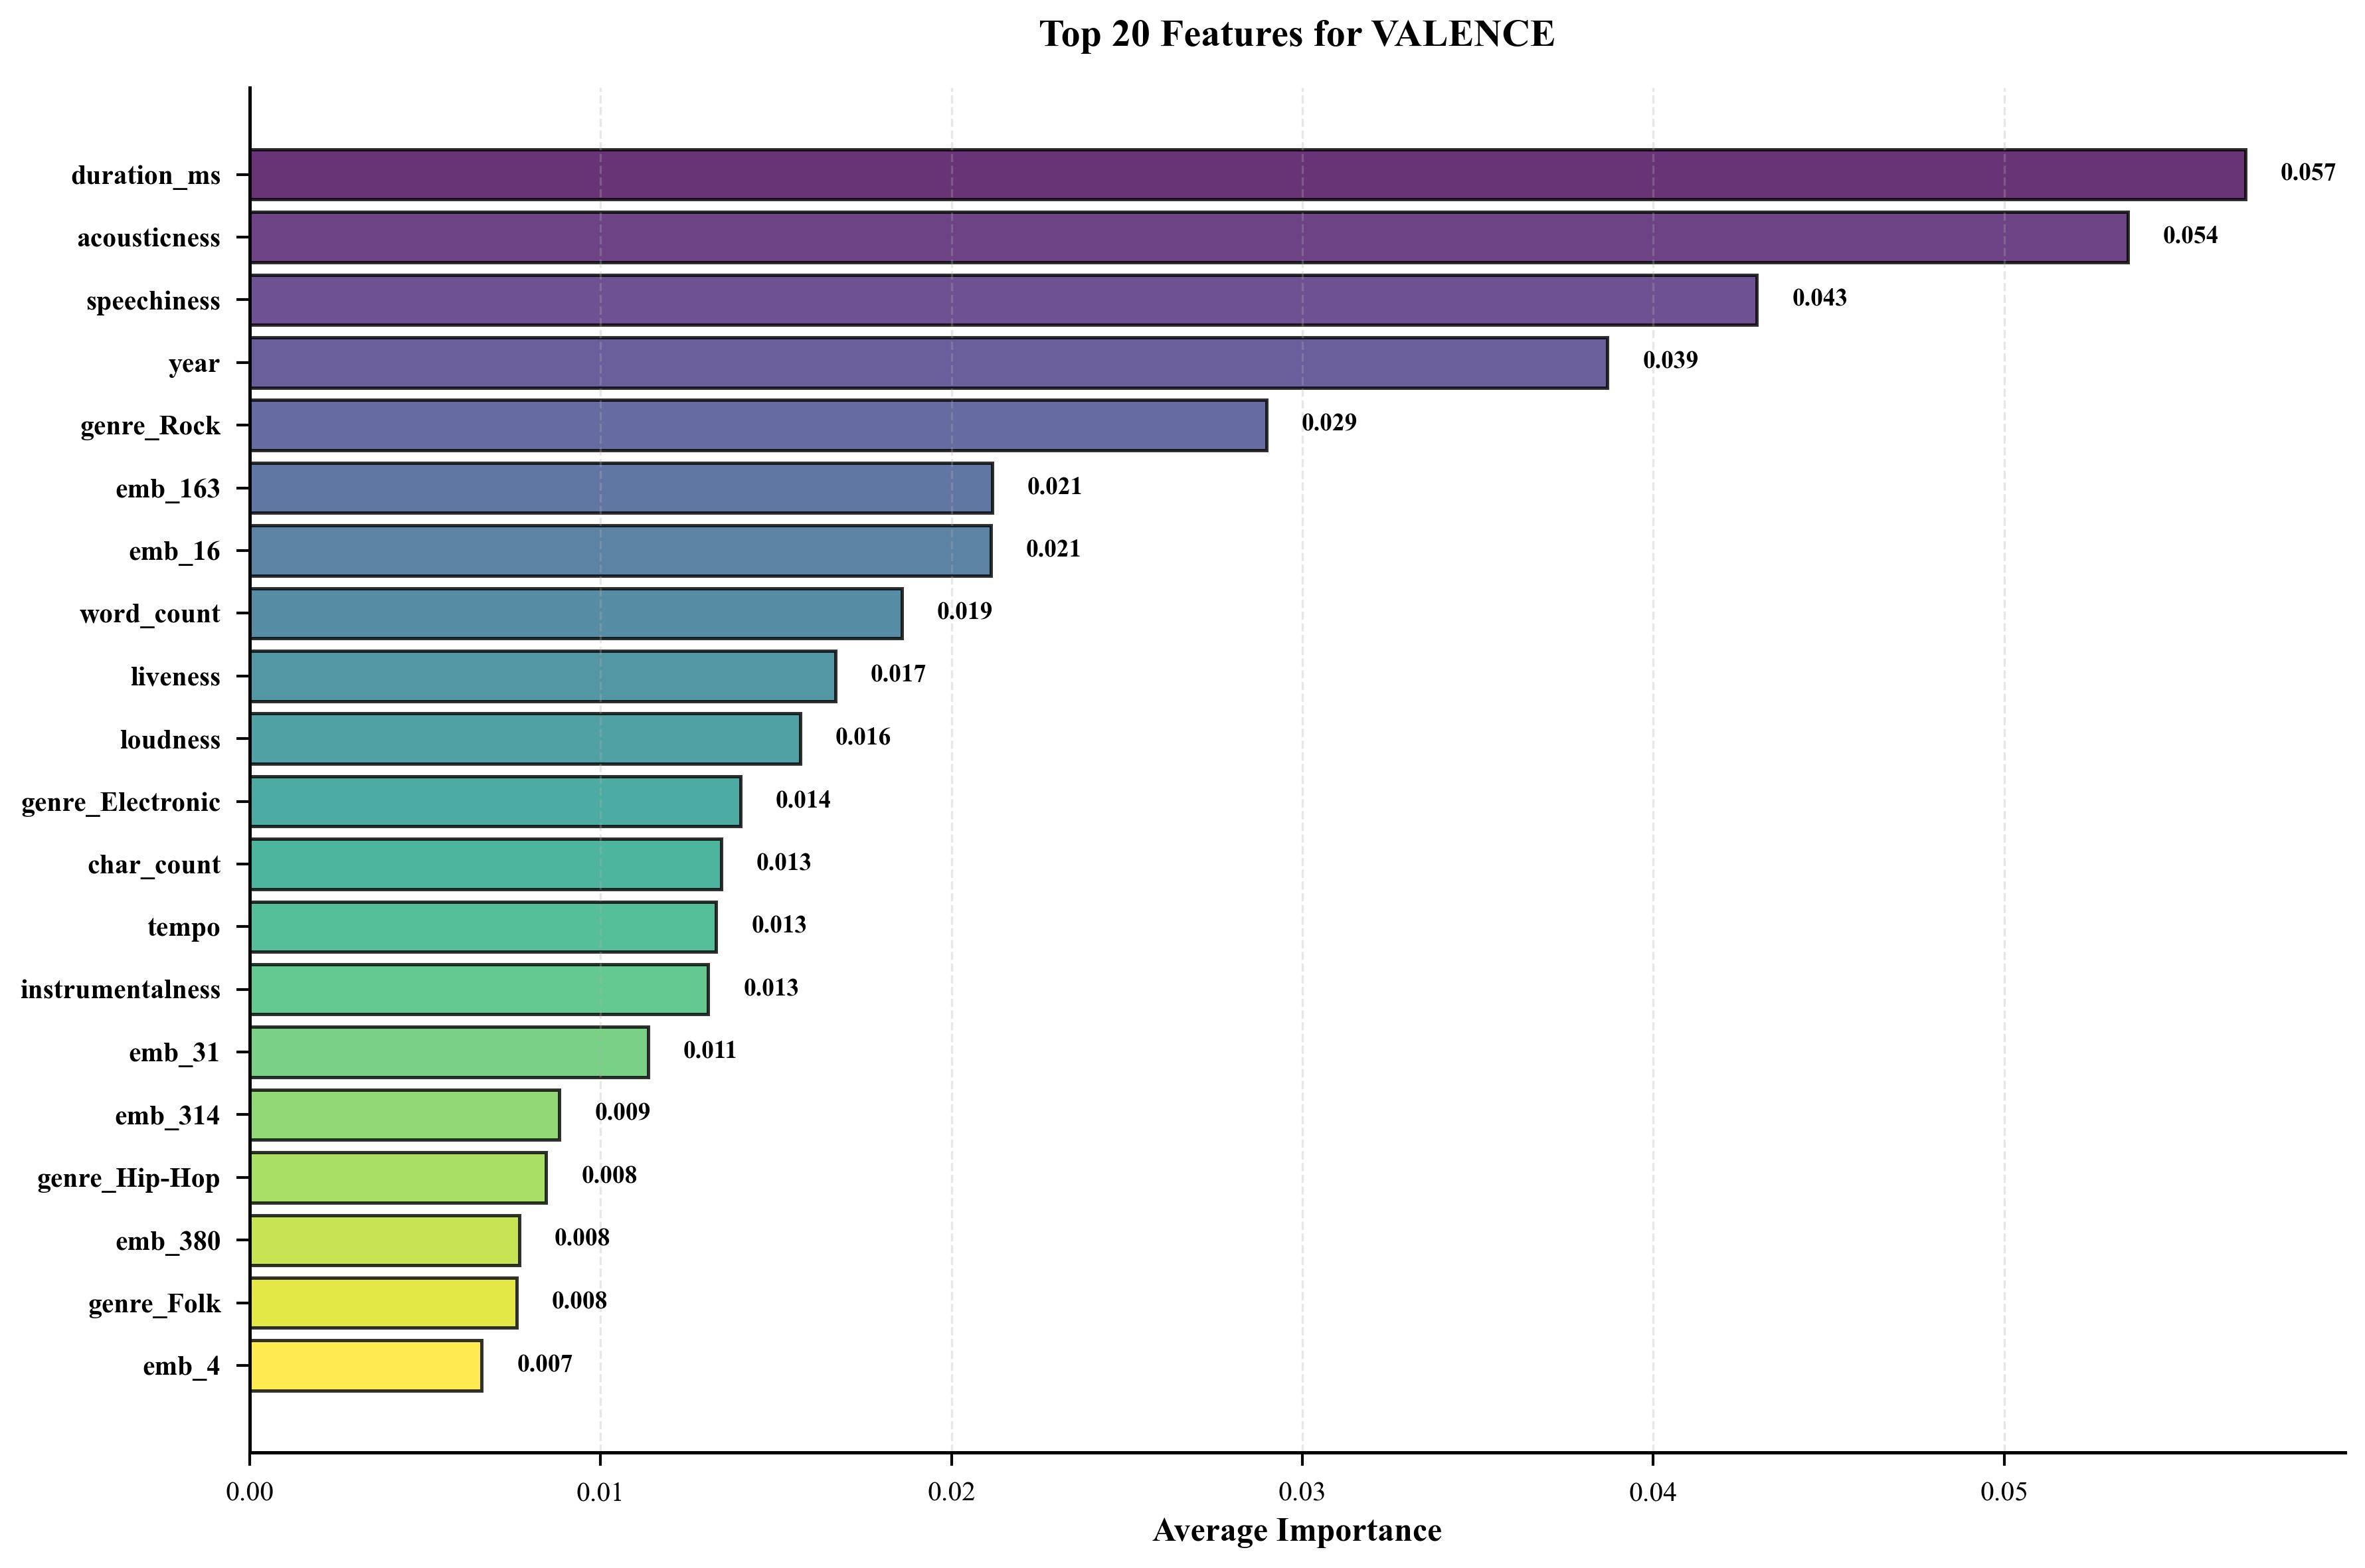

💾 Saved: feature_importance_valence.png


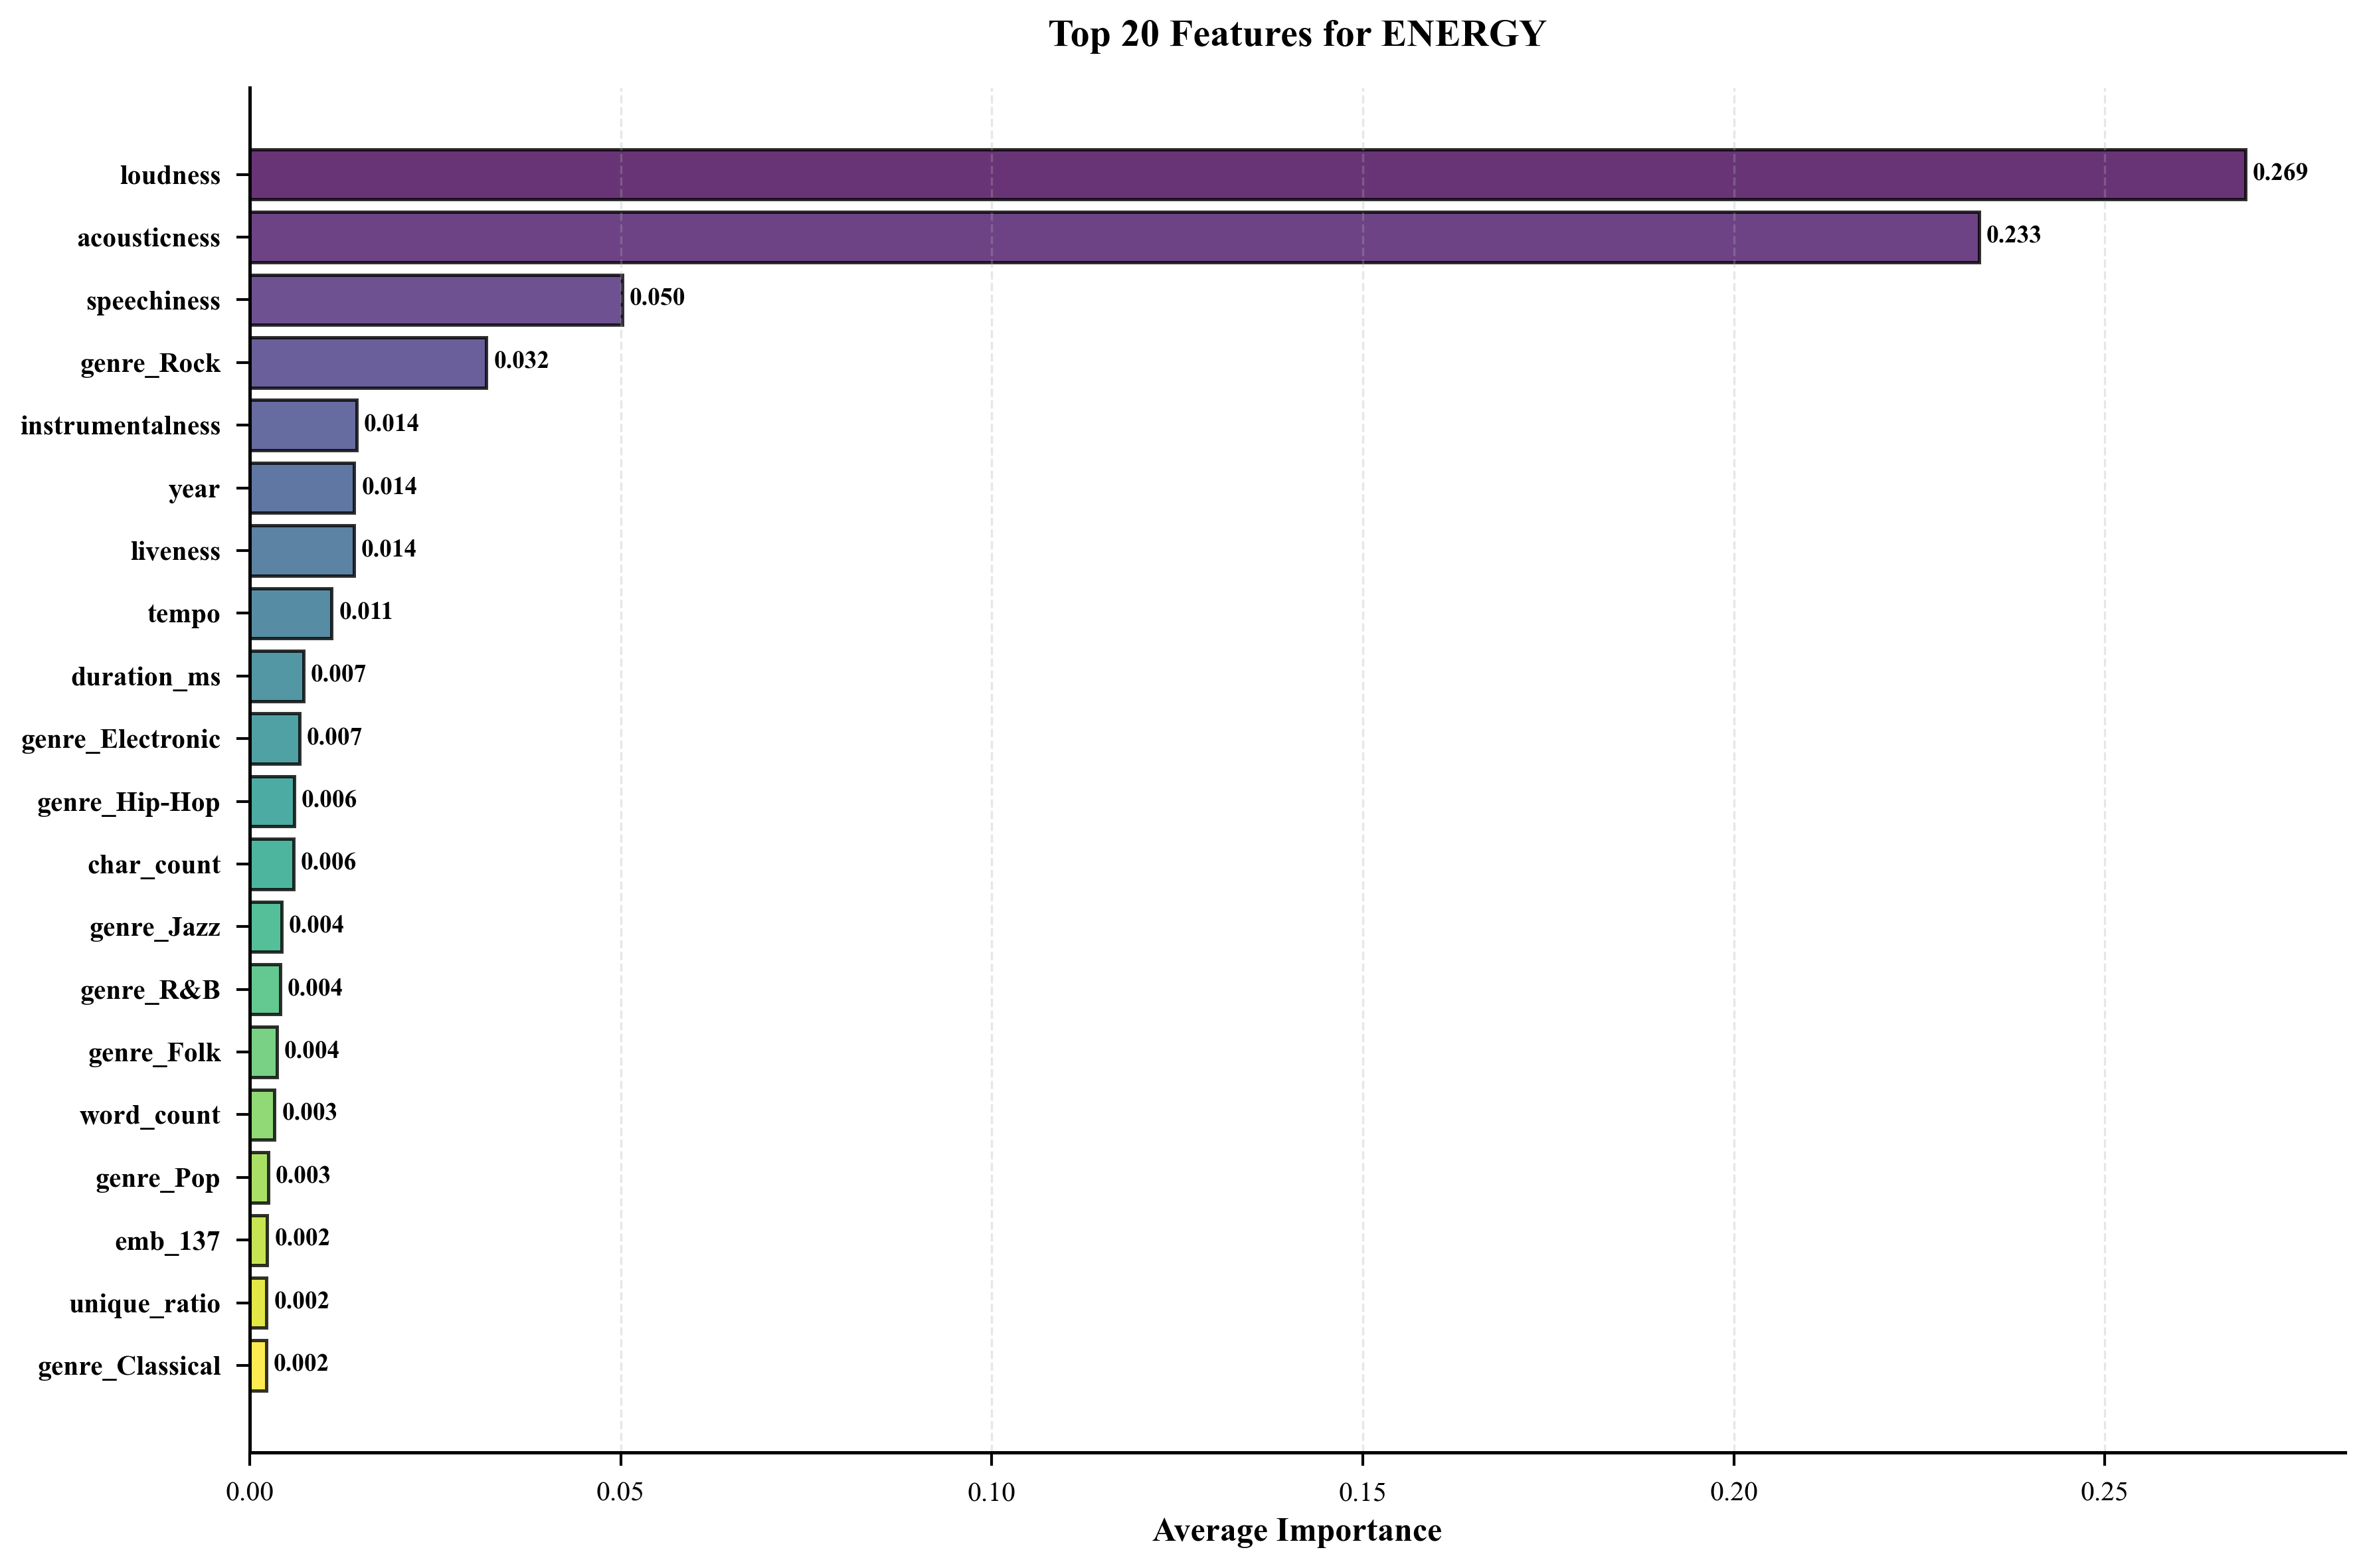

💾 Saved: feature_importance_energy.png


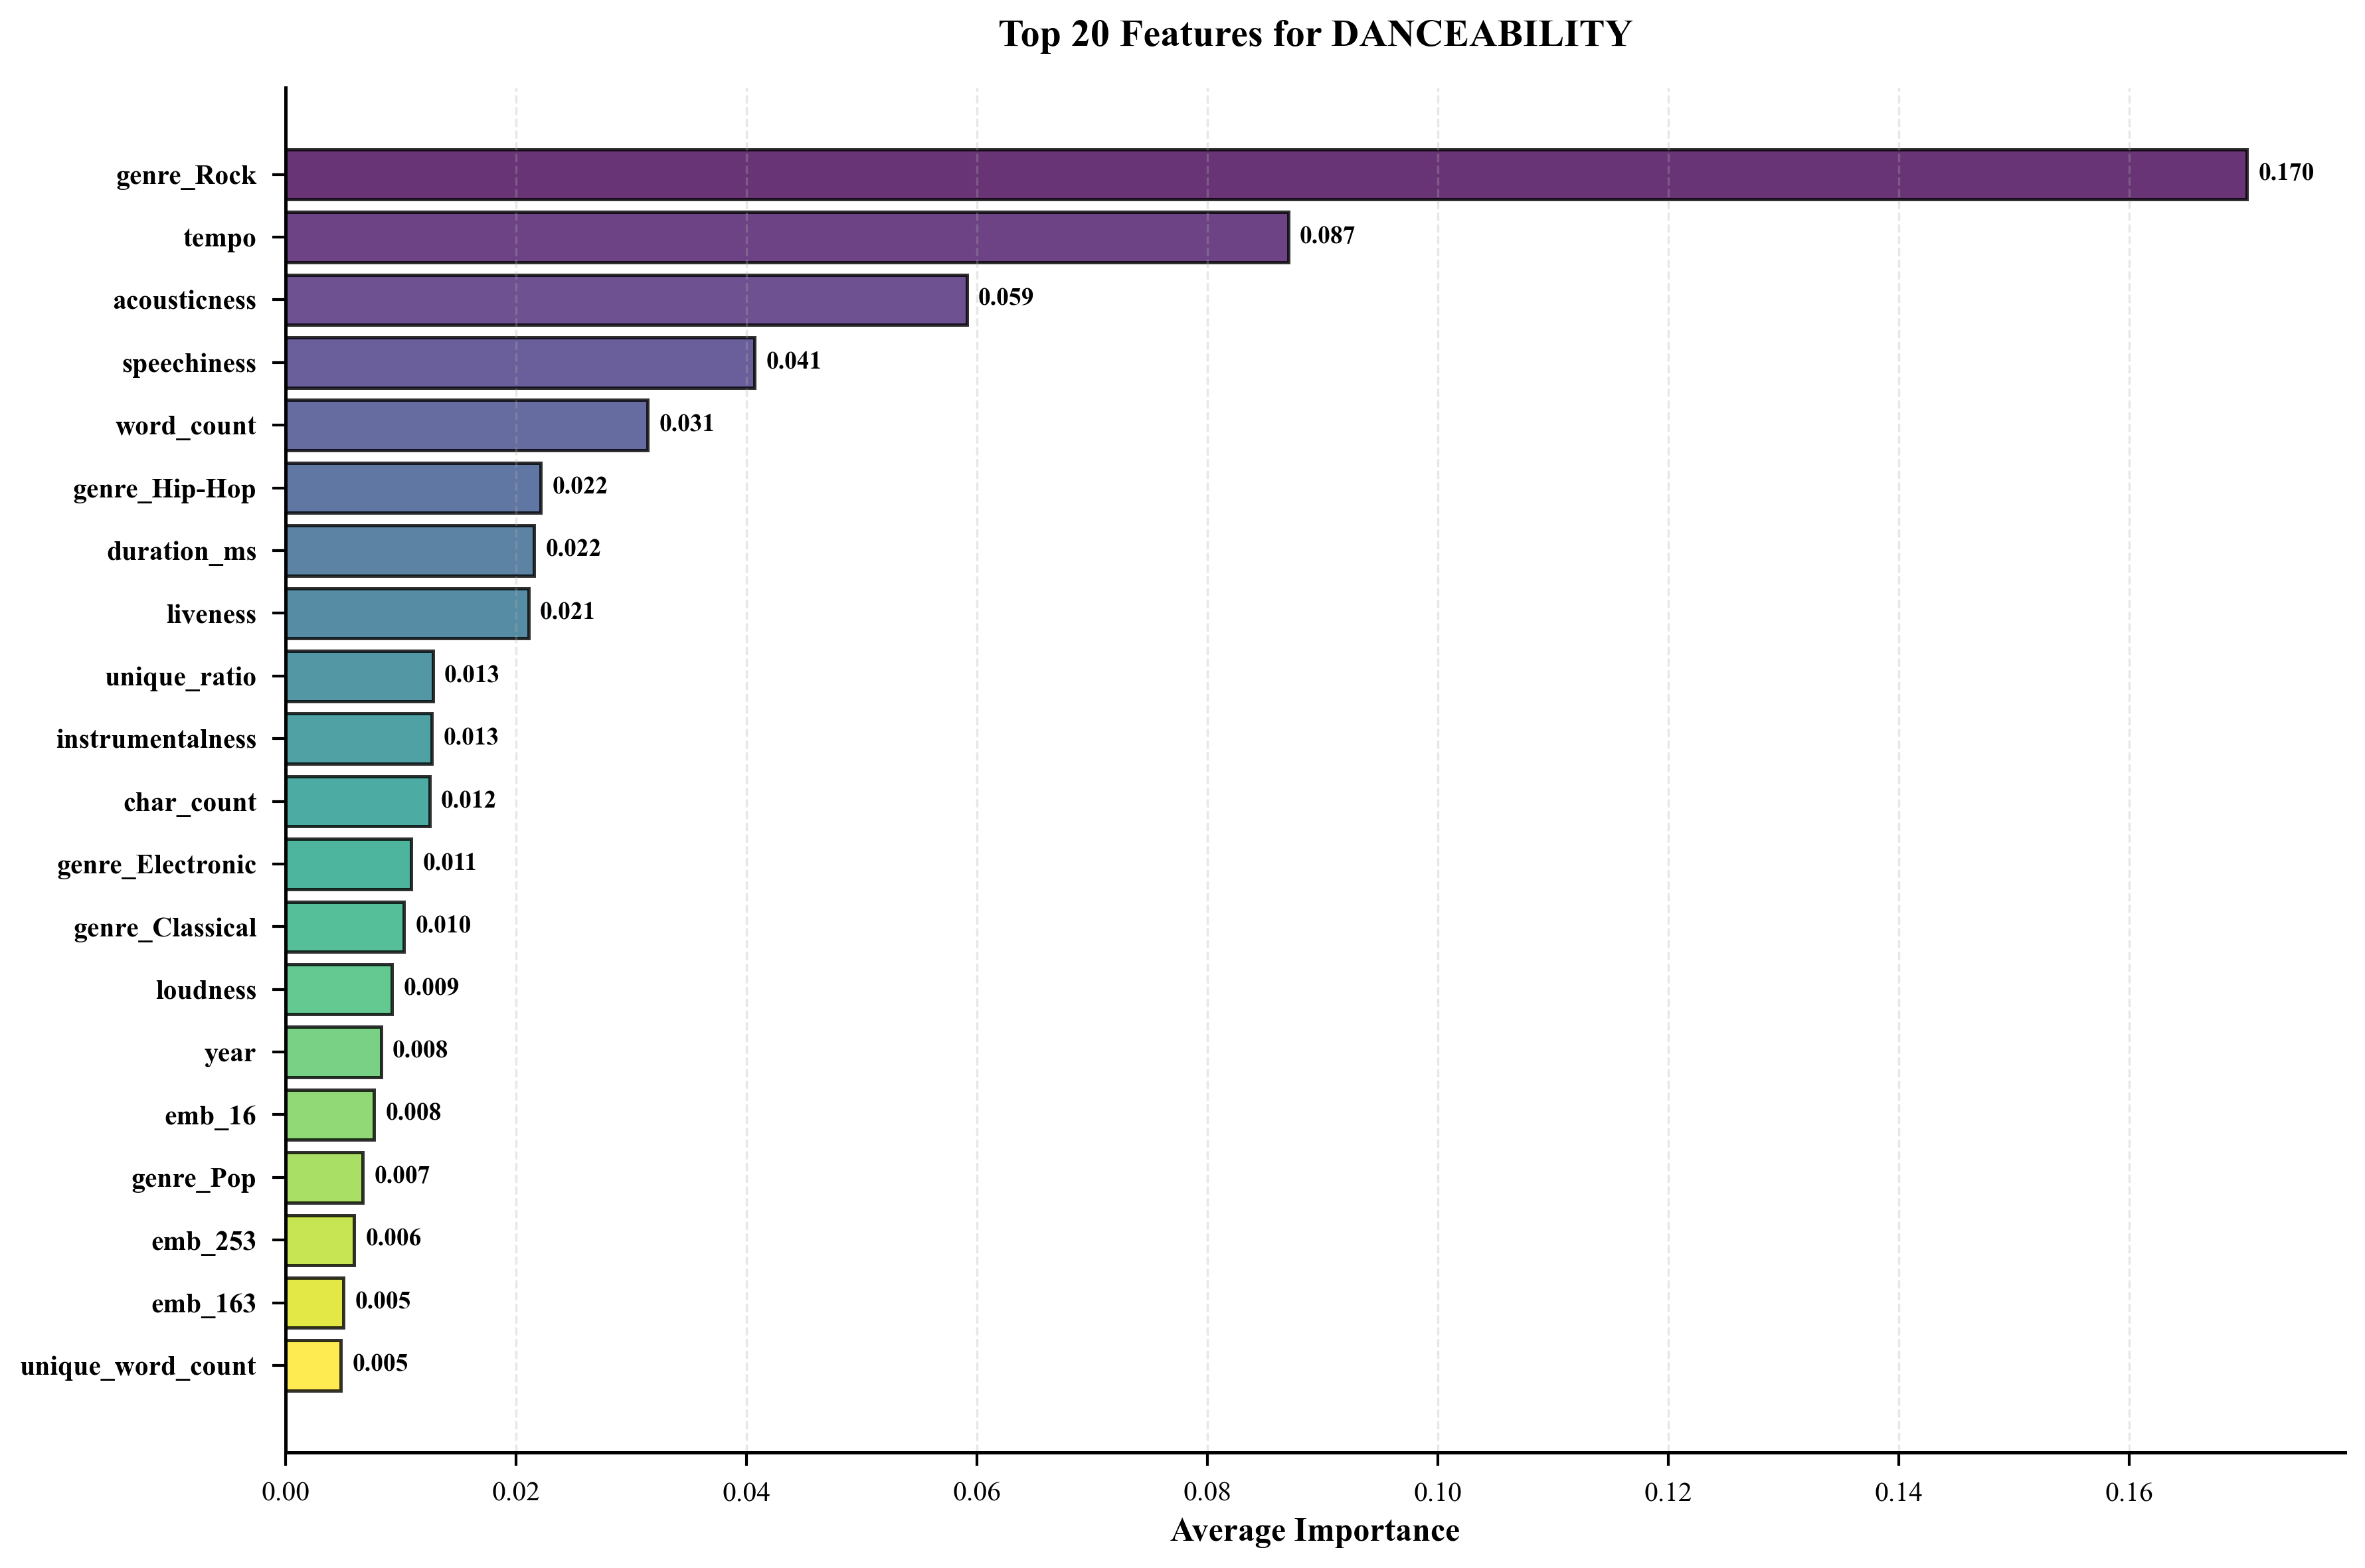

💾 Saved: feature_importance_danceability.png


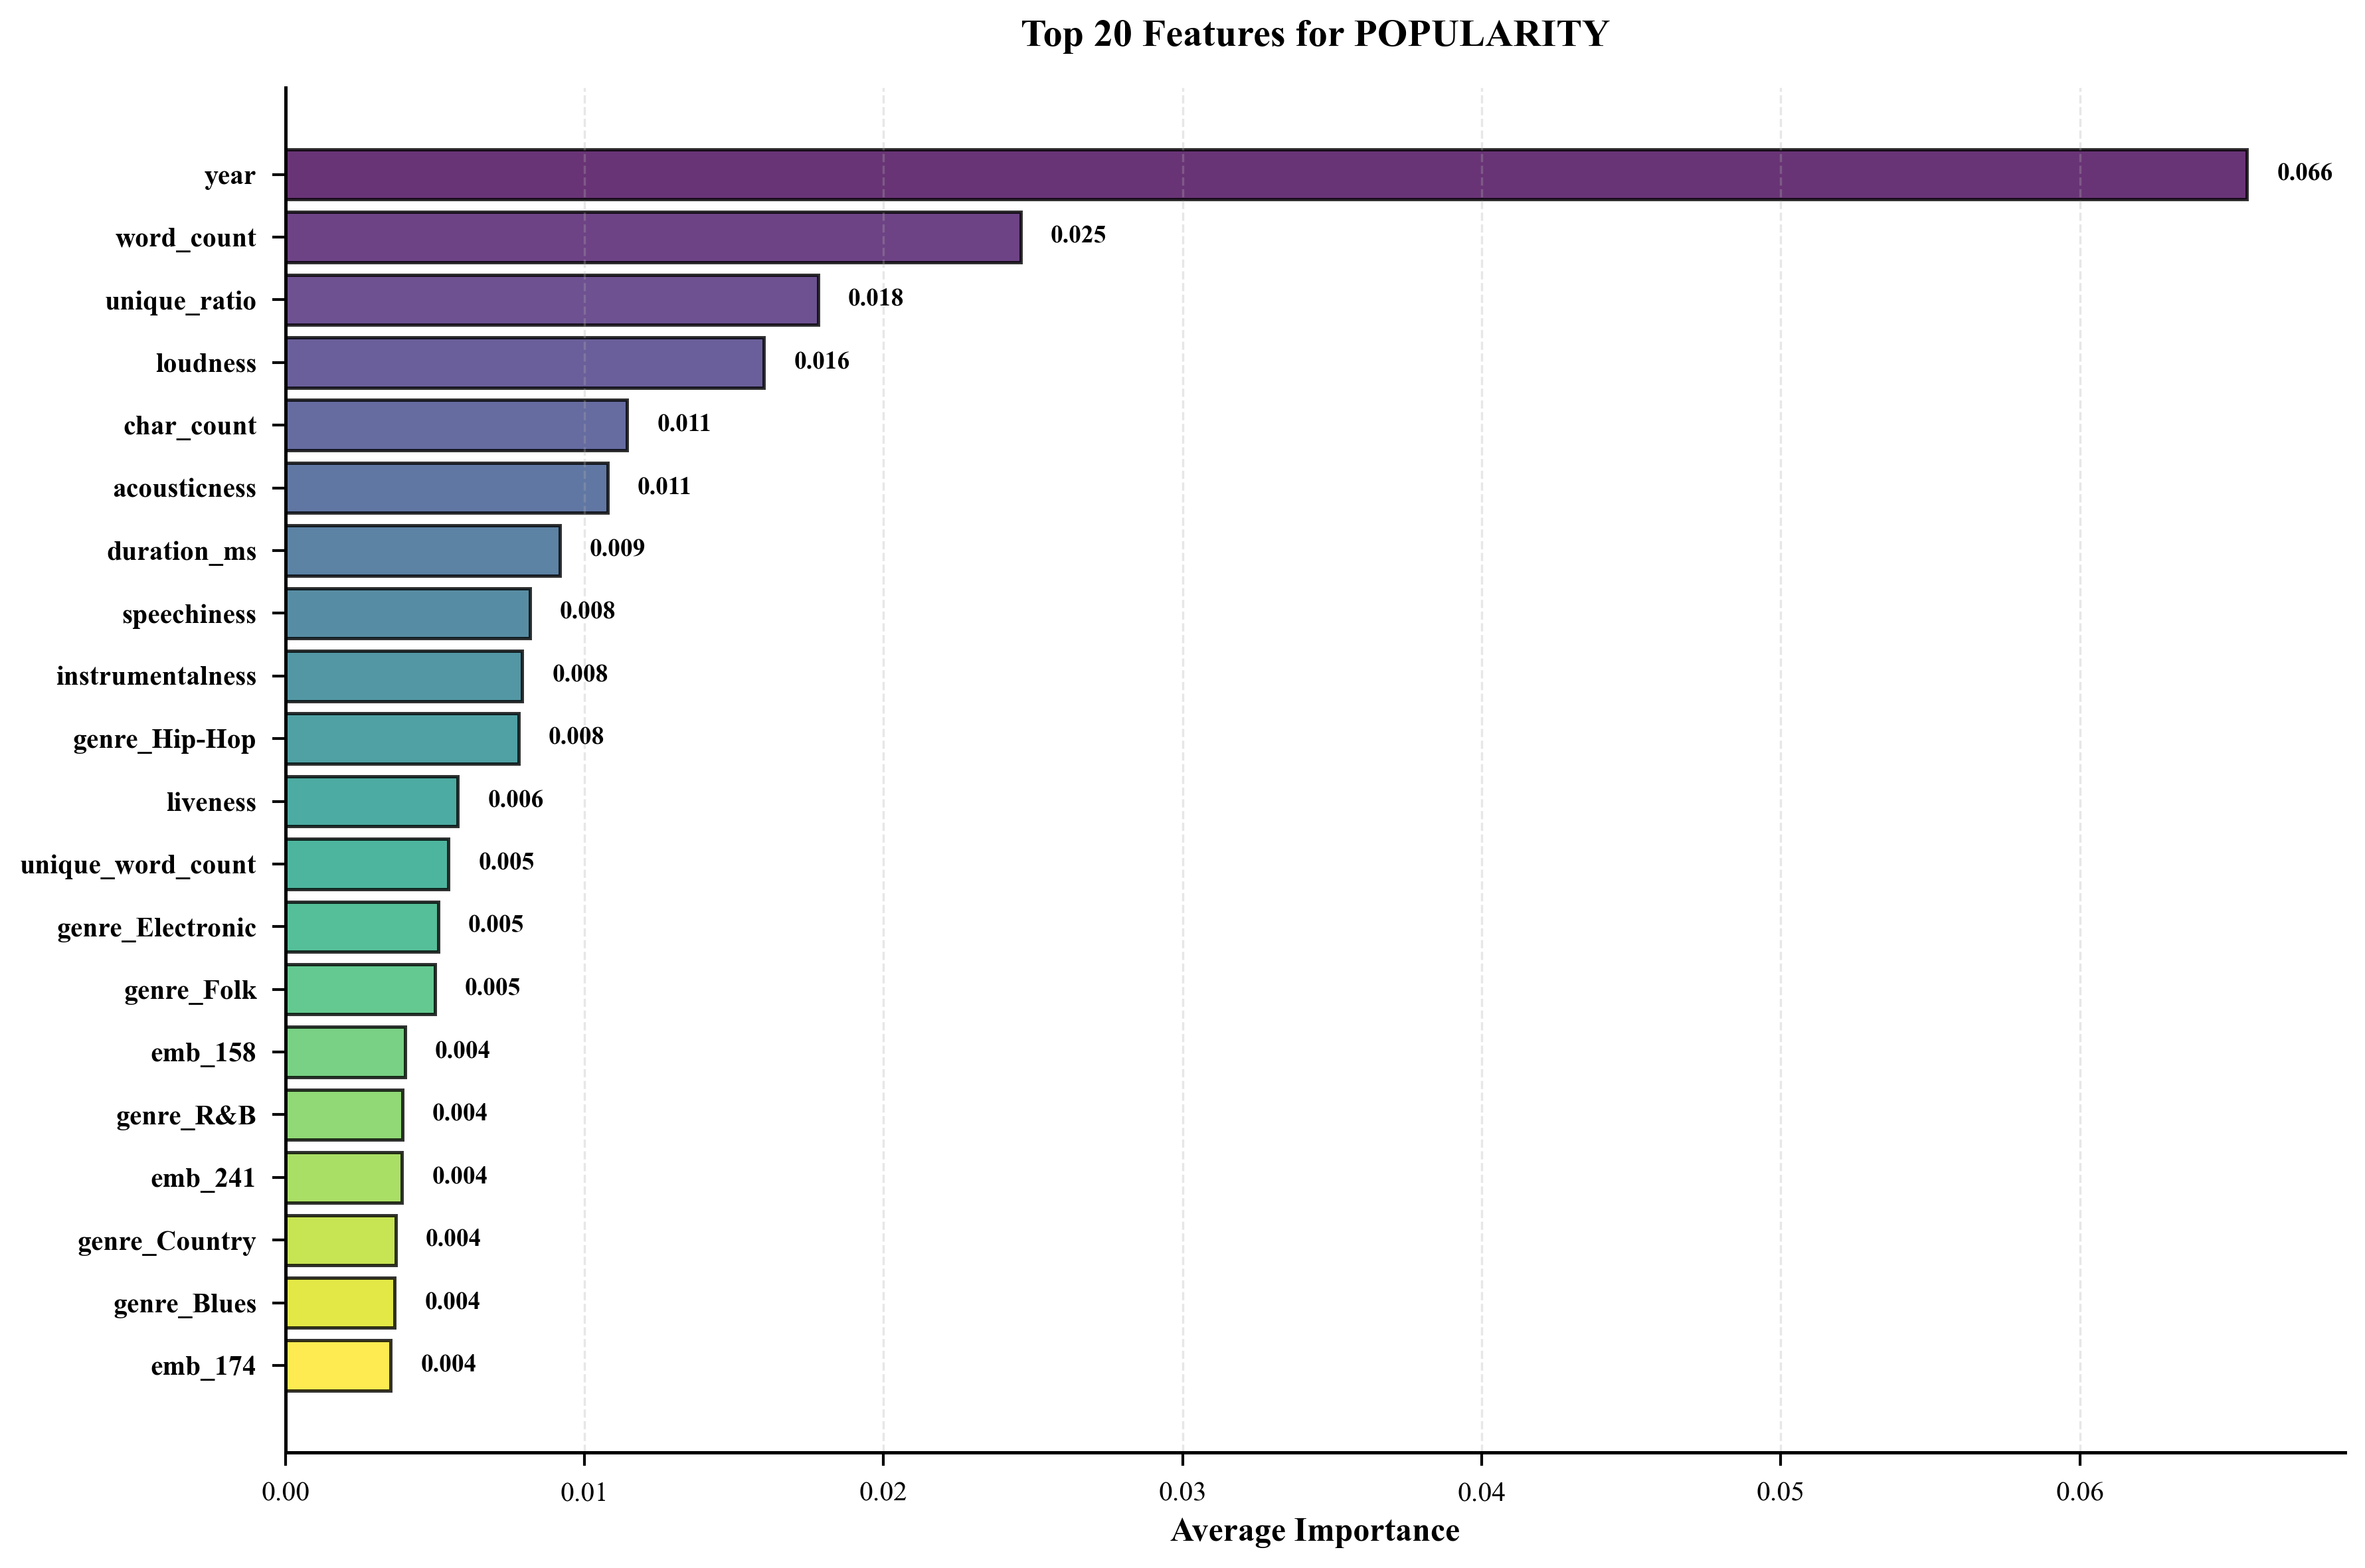

💾 Saved: feature_importance_popularity.png


In [16]:
def plot_top_features(all_importance, target, top_n=20):
    """Plot top N features for a target"""
    target_df = all_importance[all_importance['target'] == target].copy()
    agg_importance = target_df.groupby('feature')['importance'].mean().sort_values(ascending=False)
    top_features = agg_importance.head(top_n)
    
    fig, ax = plt.subplots(figsize=(12, 8))
    colors = plt.cm.viridis(np.linspace(0, 1, len(top_features)))
    
    bars = ax.barh(range(len(top_features)), top_features.values, 
                   color=colors, edgecolor='black', alpha=0.8, linewidth=1.2)
    ax.set_yticks(range(len(top_features)))
    ax.set_yticklabels(top_features.index, fontweight='bold')
    ax.invert_yaxis()
    ax.set_xlabel('Average Importance', fontsize=12, fontweight='bold')
    ax.set_title(f'Top {top_n} Features for {target.upper()}', fontsize=14, fontweight='bold', pad=15)
    ax.grid(True, alpha=0.3, axis='x', linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Add value labels
    for bar, val in zip(bars, top_features.values):
        ax.text(val + 0.001, bar.get_y() + bar.get_height()/2, 
                f'{val:.3f}', va='center', fontsize=9, fontweight='bold')
    
    plt.tight_layout()
    return fig

# Generate plots
for target in TARGETS:
    fig = plot_top_features(all_importance_df, target, top_n=20)
    fig_path = FIGURES_DIR / f"feature_importance_{target}.png"
    fig.savefig(fig_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"💾 Saved: {fig_path.name}")

---
## 📊 Visualization 2: Feature Group Importance

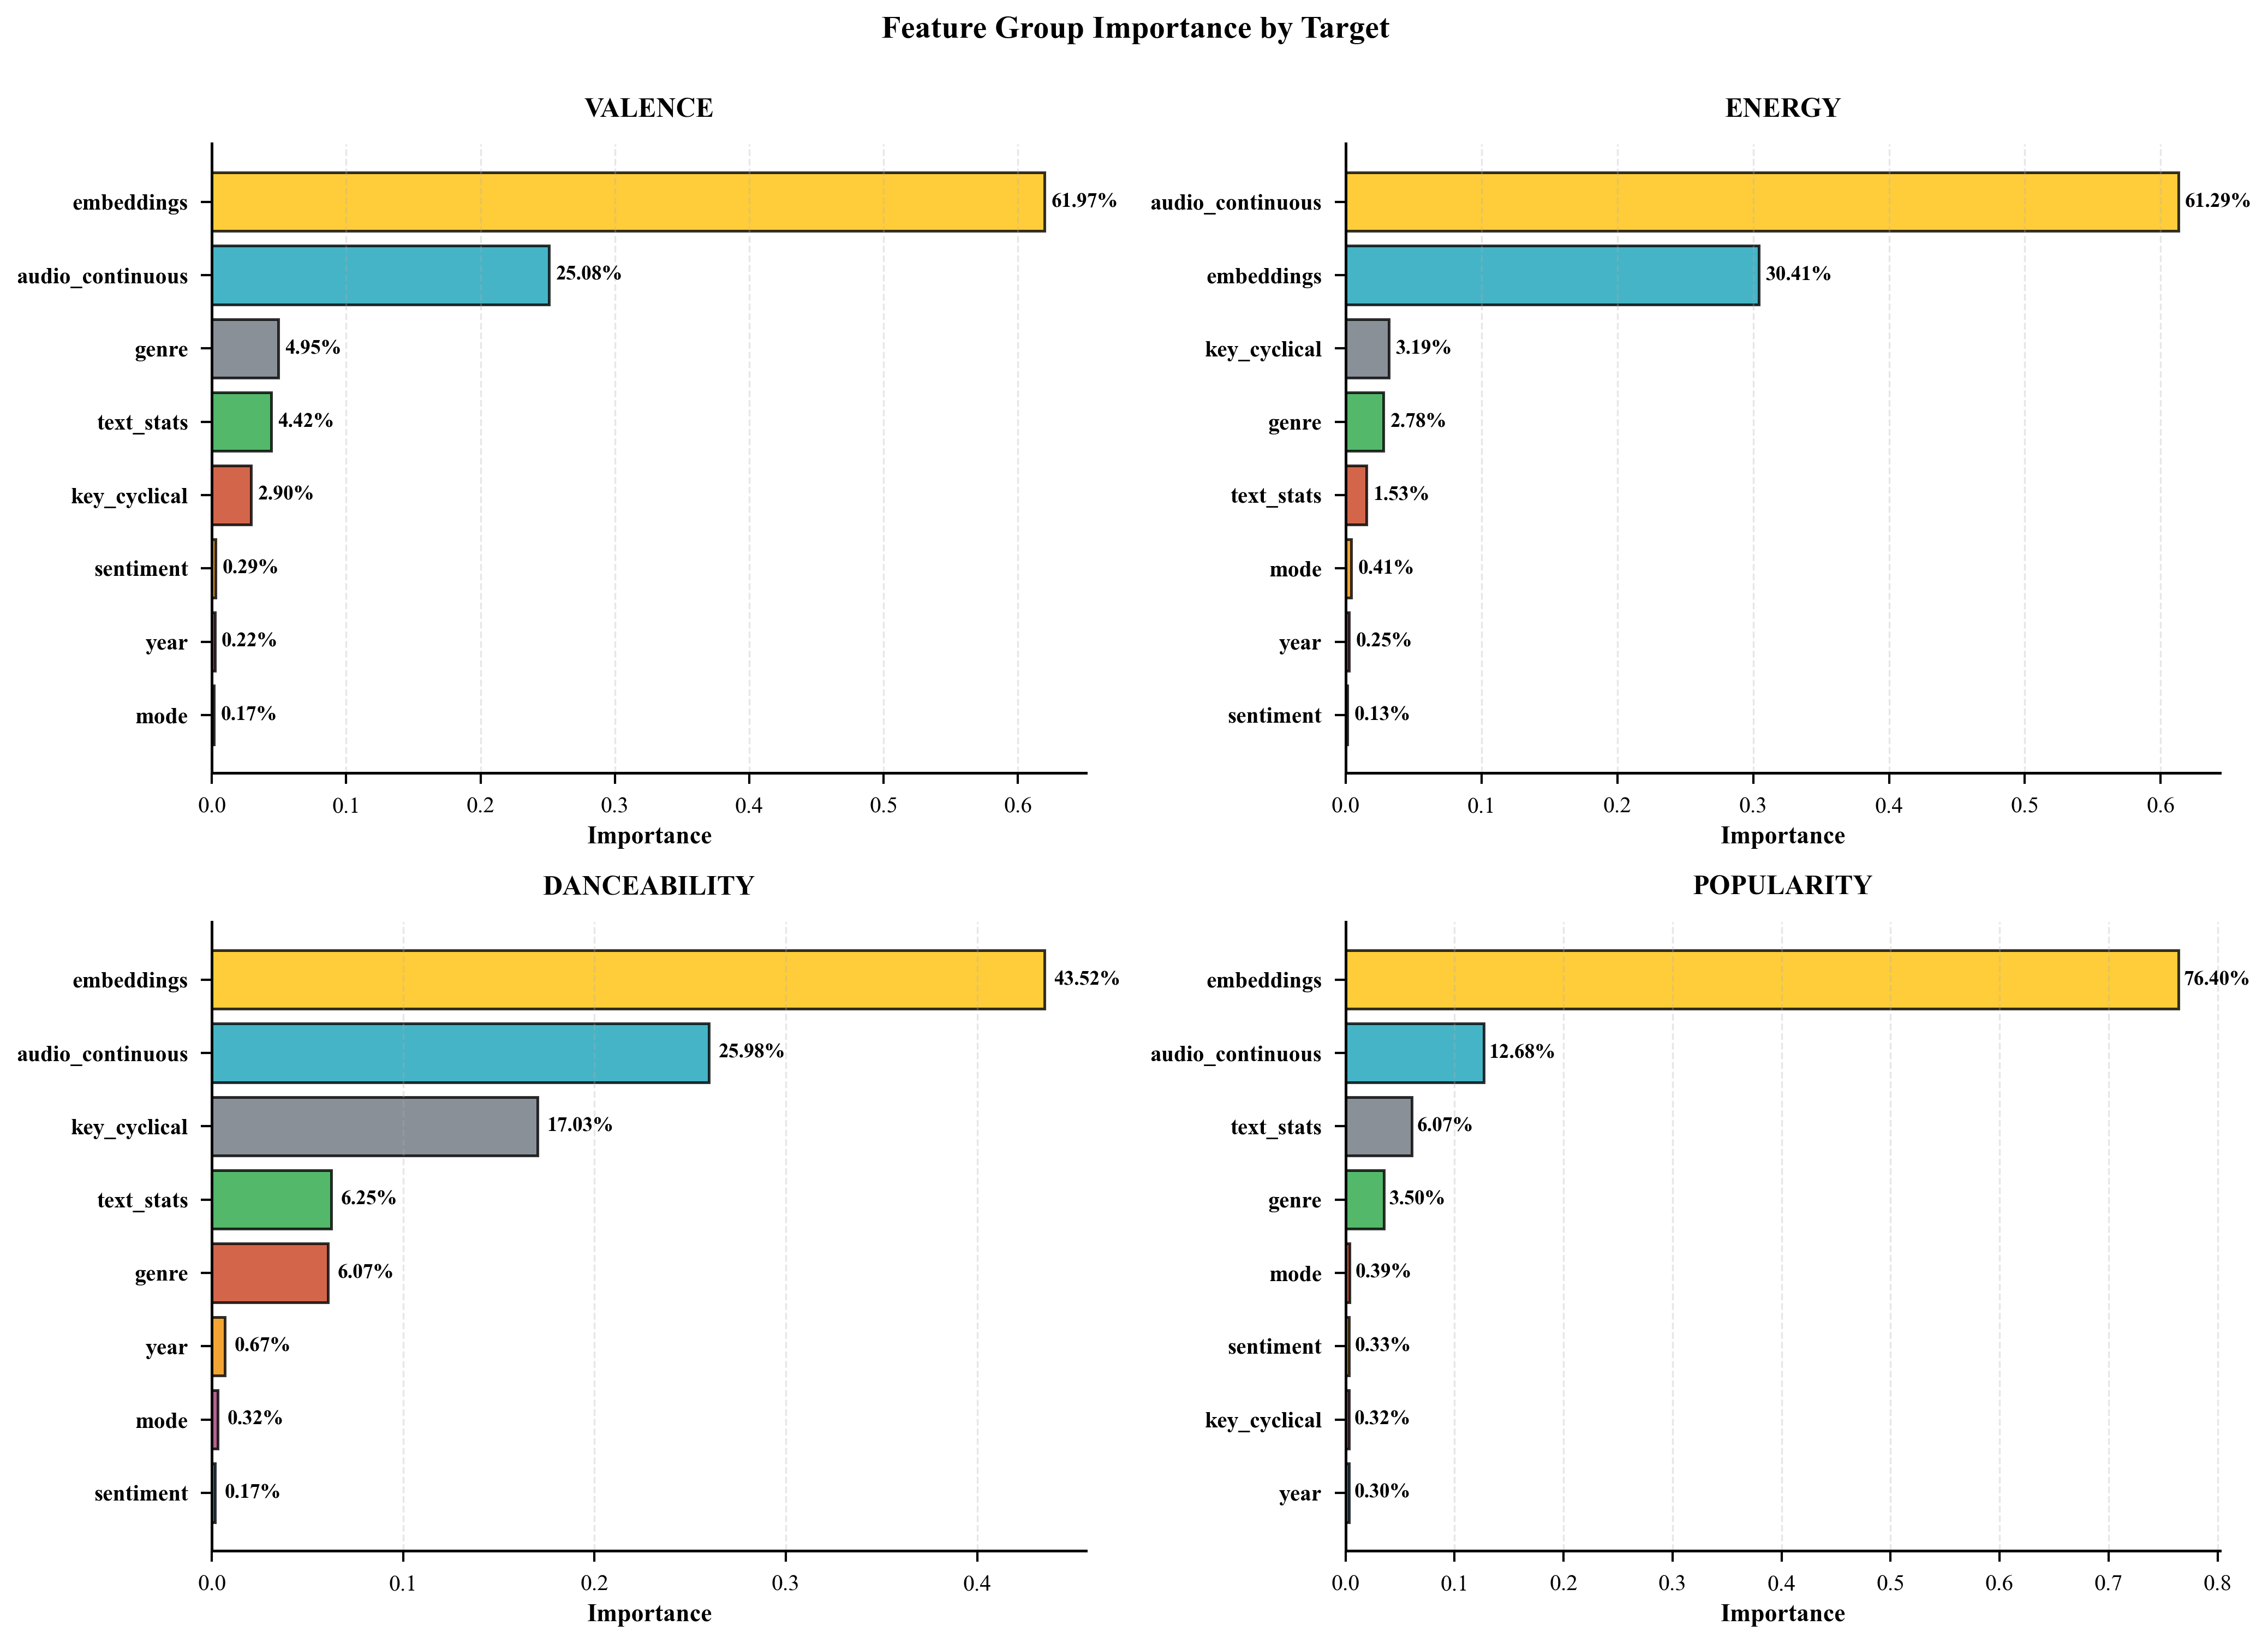

💾 Saved: feature_group_importance.png


In [17]:
def create_feature_groups():
    """Define feature groups"""
    groups = {
        'audio_continuous': list(range(0, 8)),
        'genre': list(range(8, 18)),
        'year': [18],
        'mode': [19],
        'key_cyclical': [20],
        'text_stats': list(range(21, 26)),
        'sentiment': list(range(26, 28)),
        'embeddings': list(range(28, 412)),
    }
    return groups

def aggregate_by_group(importance_df, feature_names):
    """Aggregate feature importance by group"""
    groups = create_feature_groups()
    group_importance = {}
    
    for group_name, indices in groups.items():
        group_features = [feature_names[i] for i in indices if i < len(feature_names)]
        mask = importance_df['feature'].isin(group_features)
        group_importance[group_name] = importance_df.loc[mask, 'importance'].sum()
    
    return pd.Series(group_importance).sort_values(ascending=False)

# Plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#28A745', '#6C757D', '#17A2B8', '#FFC107']

for ax, target in zip(axes.flatten(), TARGETS):
    target_df = all_importance_df[all_importance_df['target'] == target]
    
    # Aggregate by group
    group_data = []
    for model in target_df['model'].unique():
        model_df = target_df[target_df['model'] == model]
        group_imp = aggregate_by_group(model_df, feature_names)
        group_data.append(group_imp)
    
    # Average across models
    group_df = pd.DataFrame(group_data)
    avg_group = group_df.mean().sort_values(ascending=True)
    
    bars = ax.barh(range(len(avg_group)), avg_group.values, 
                  color=colors[:len(avg_group)], edgecolor='black', alpha=0.8, linewidth=1.2)
    ax.set_yticks(range(len(avg_group)))
    ax.set_yticklabels(avg_group.index, fontweight='bold')
    ax.set_xlabel('Importance', fontsize=11, fontweight='bold')
    ax.set_title(f'{target.upper()}', fontsize=12, fontweight='bold', pad=12)
    ax.grid(True, alpha=0.3, axis='x', linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Add value labels
    for bar, val in zip(bars, avg_group.values):
        ax.text(val + 0.005, bar.get_y() + bar.get_height()/2, 
                f'{val:.2%}', va='center', fontsize=9, fontweight='bold')

plt.suptitle('Feature Group Importance by Target', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
fig_path = FIGURES_DIR / "feature_group_importance.png"
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"💾 Saved: {fig_path.name}")

---
## 🔥 Visualization 3: Model Comparison Heatmaps

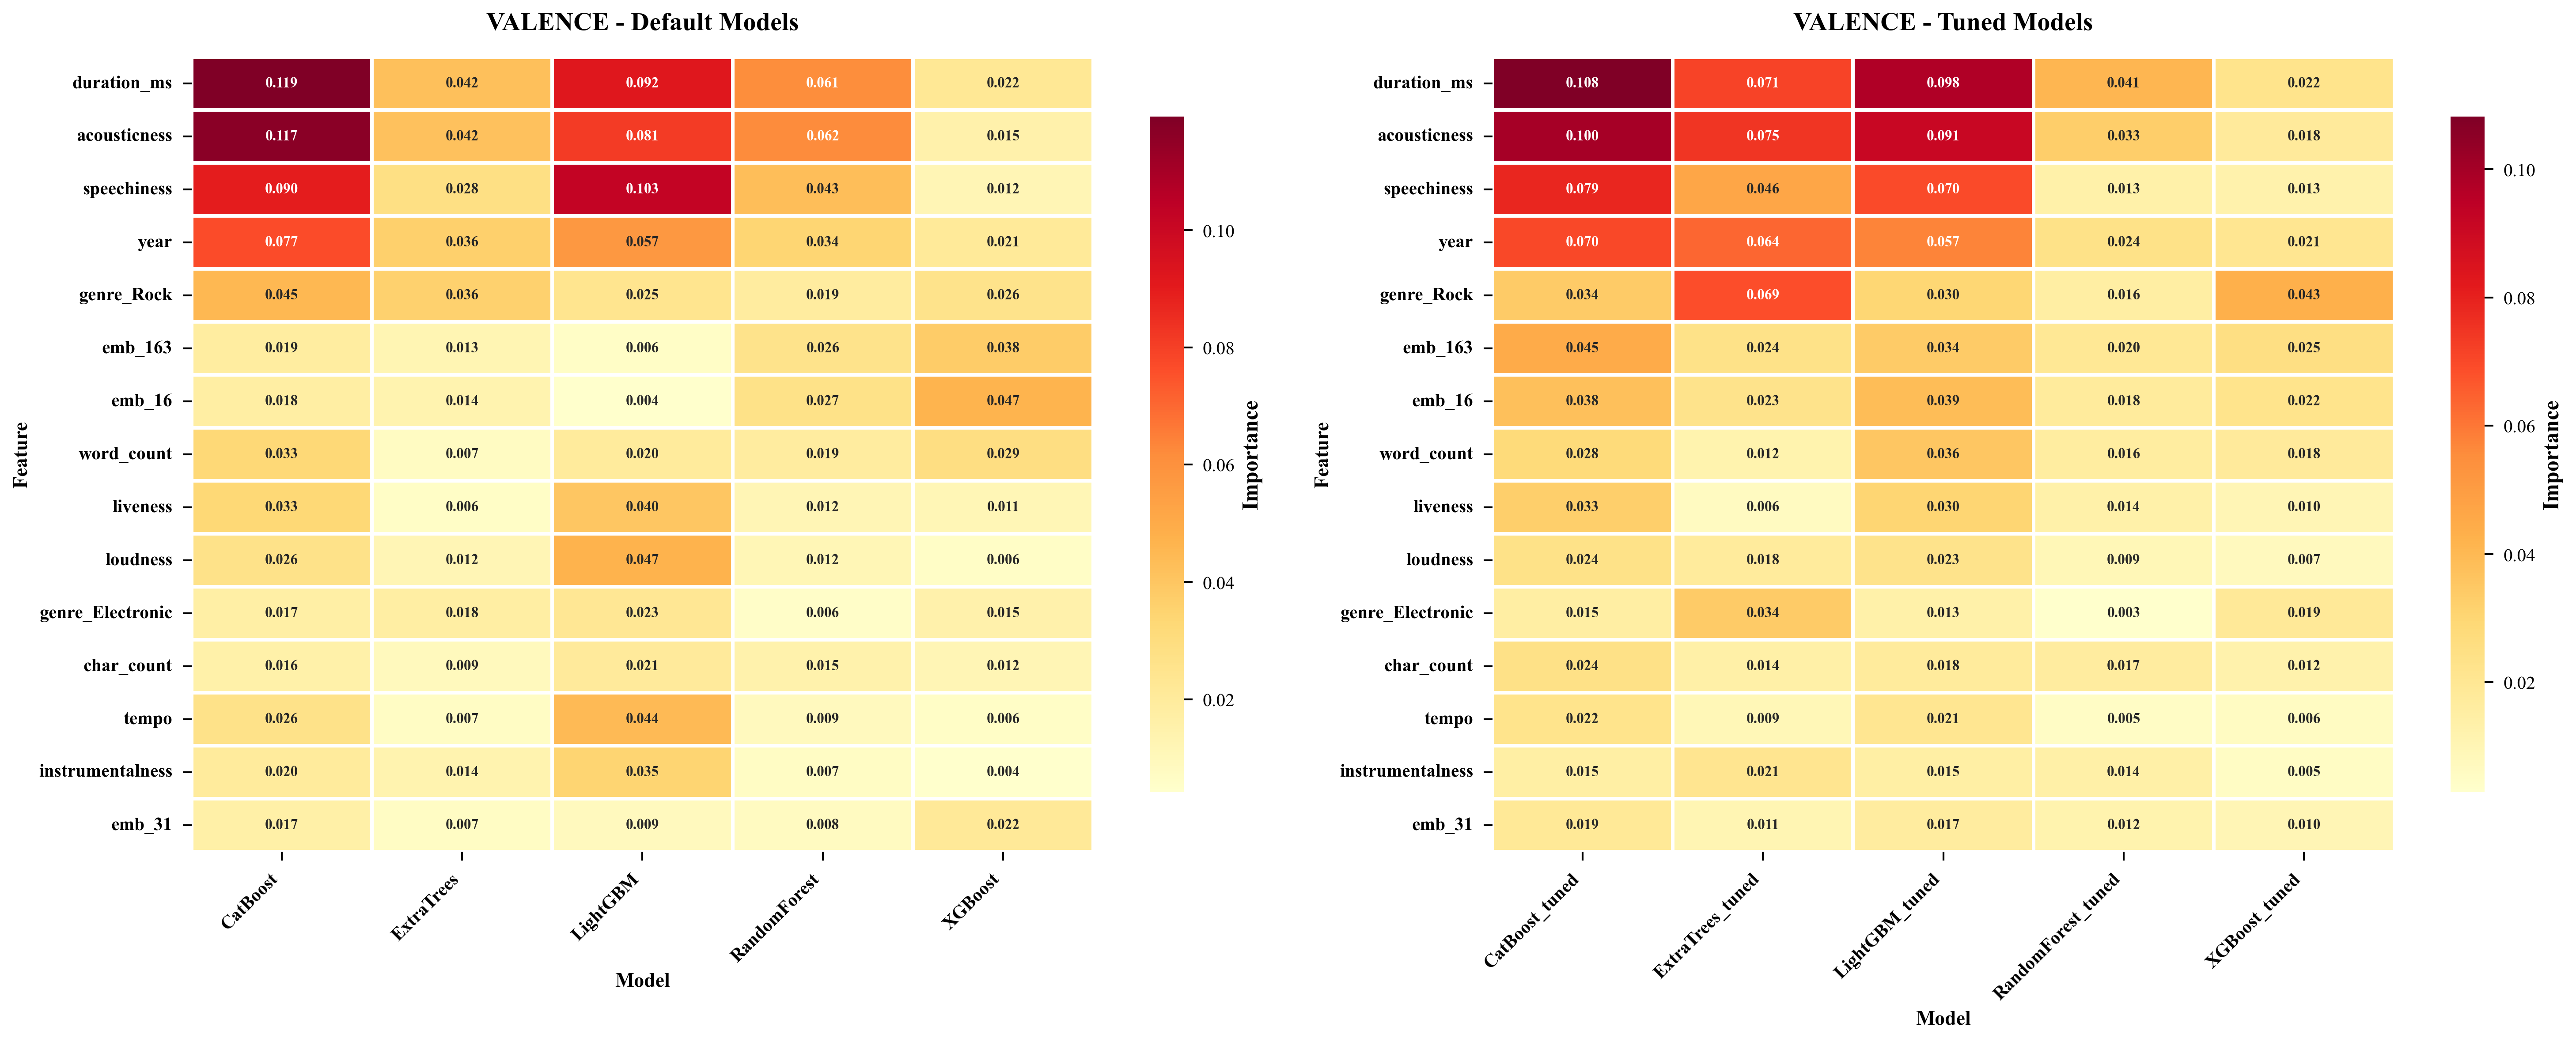

💾 Saved: feature_importance_heatmap_valence.png


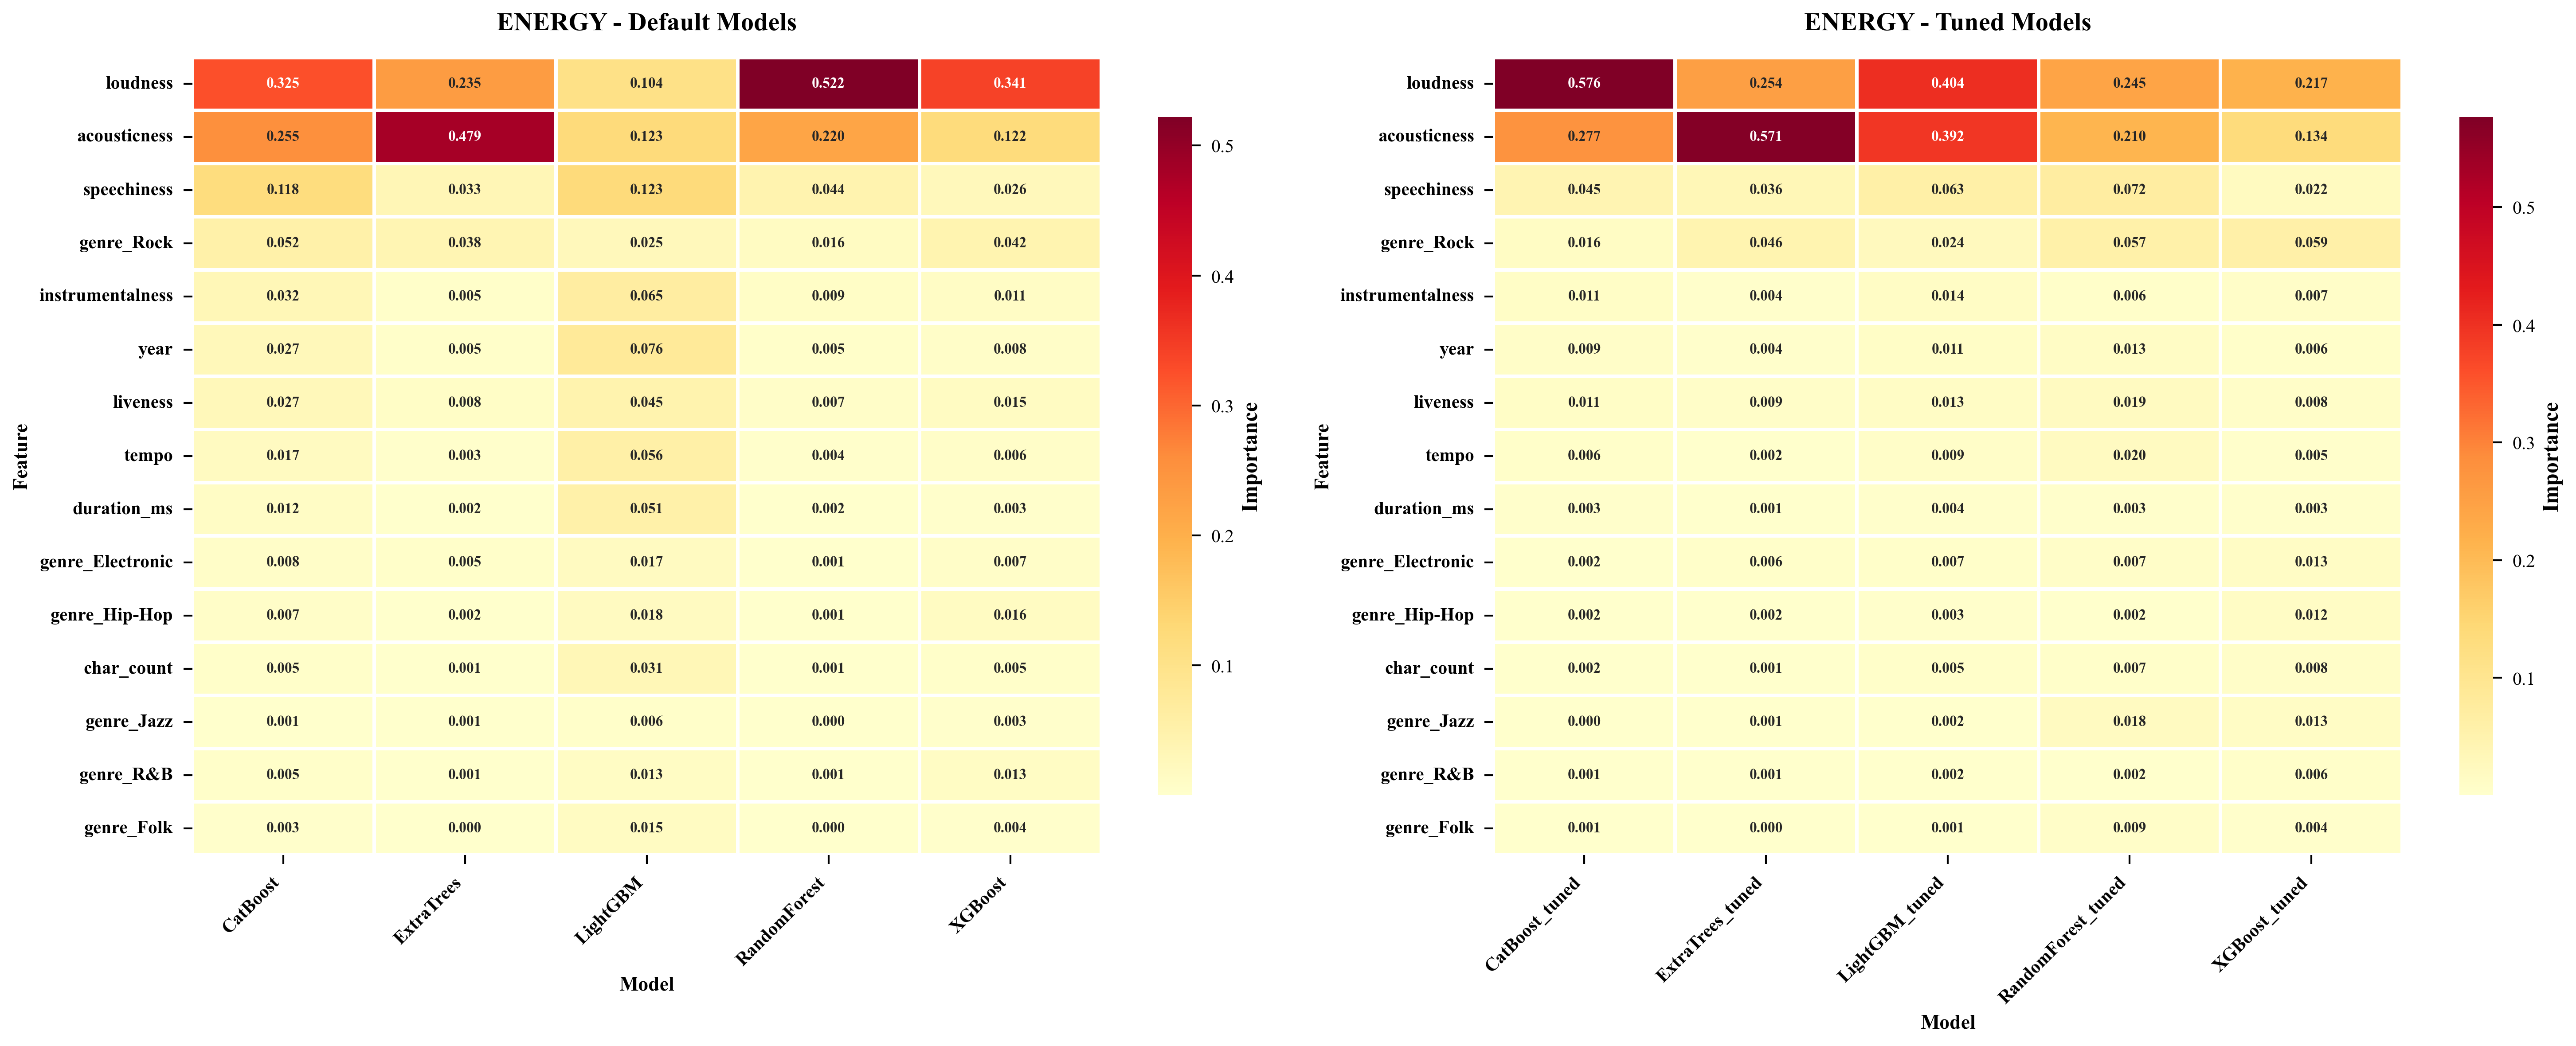

💾 Saved: feature_importance_heatmap_energy.png


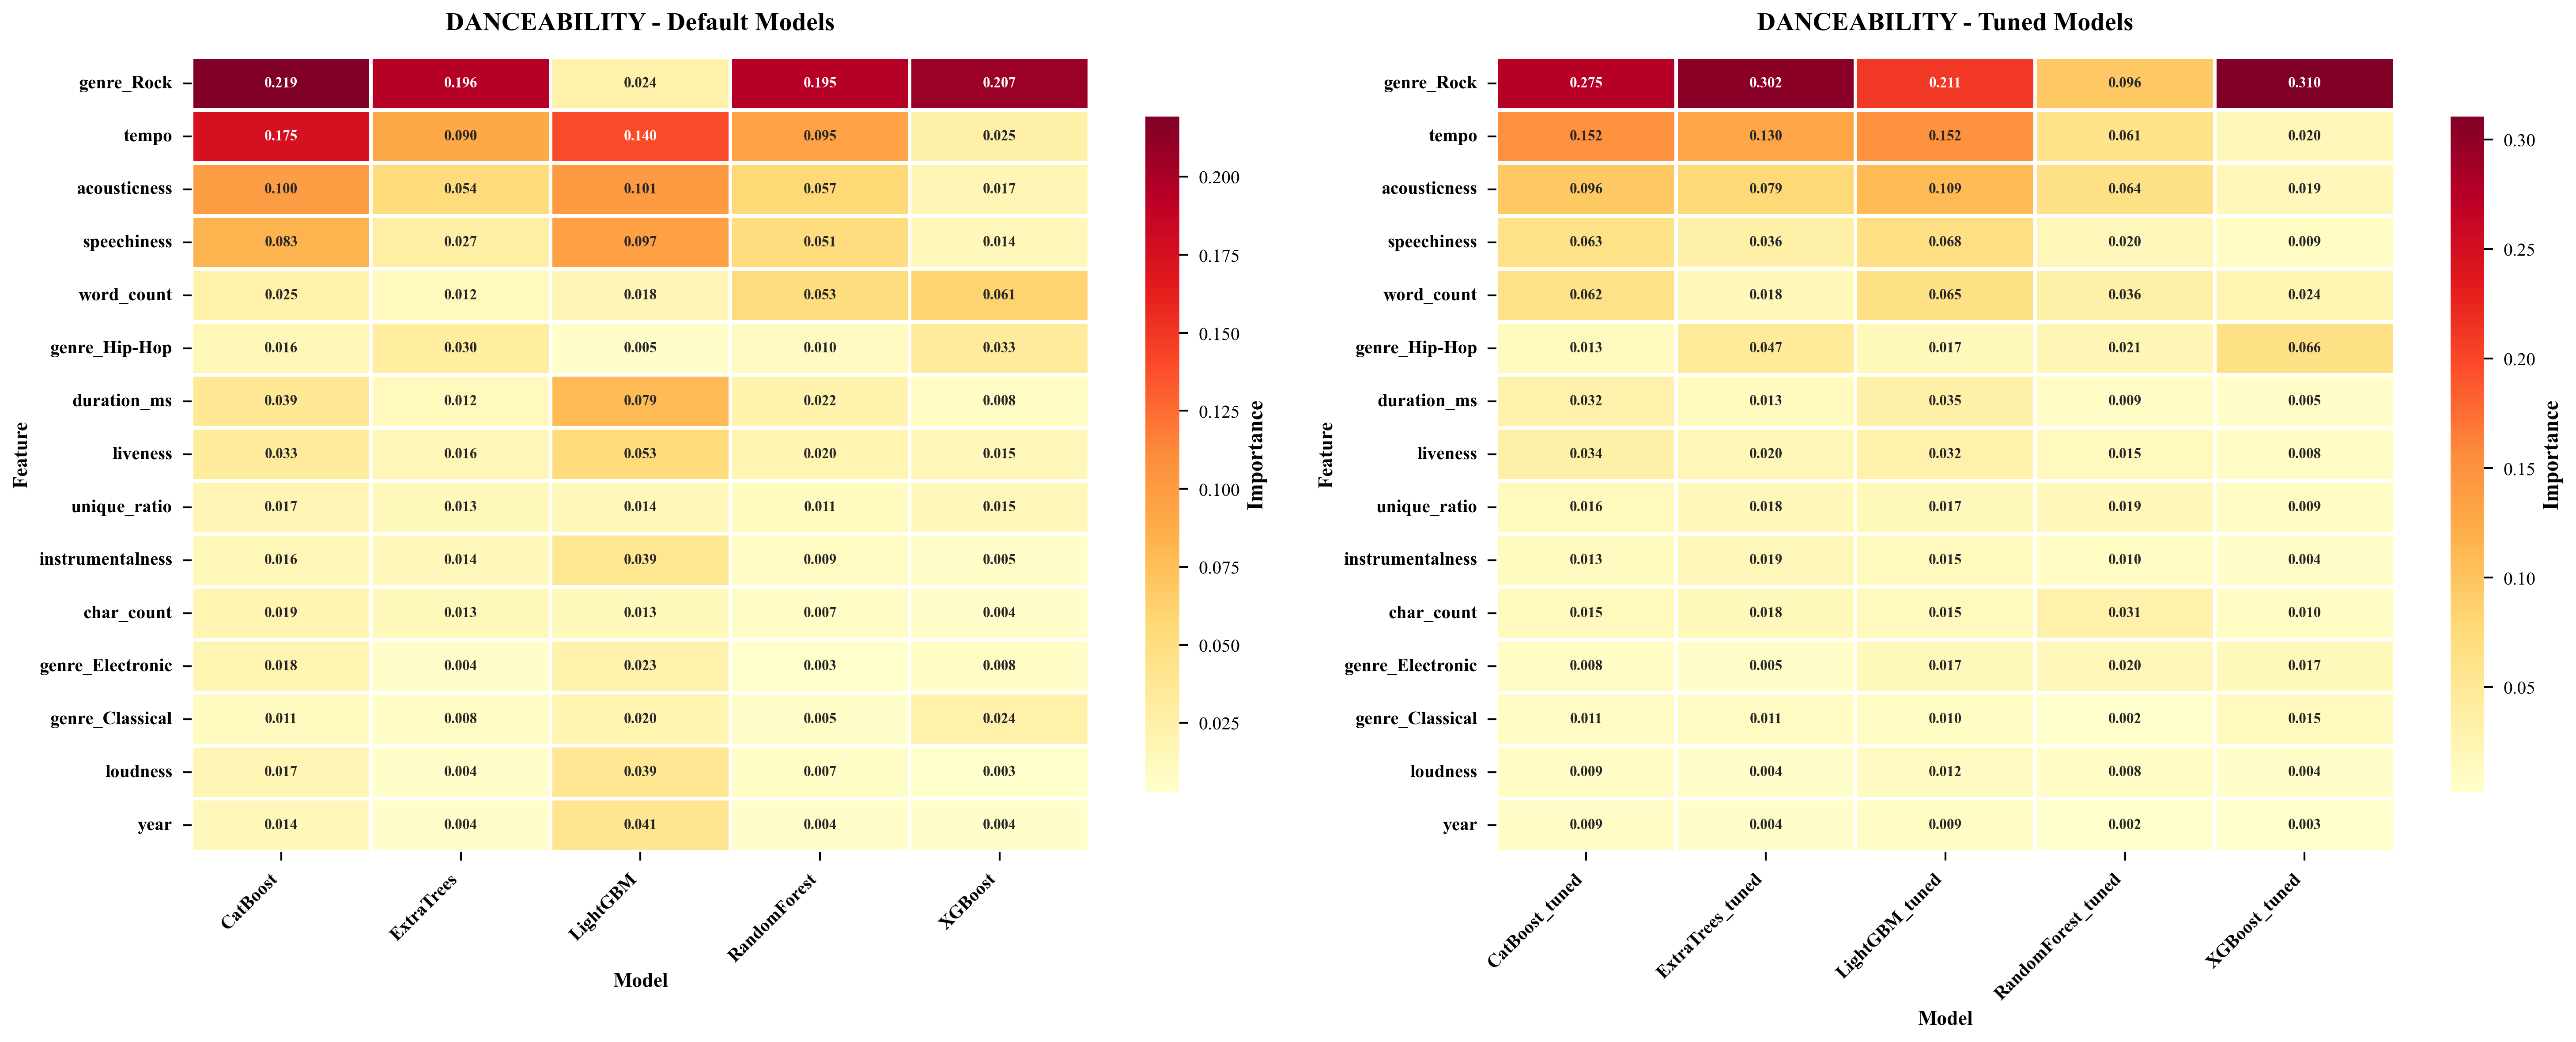

💾 Saved: feature_importance_heatmap_danceability.png


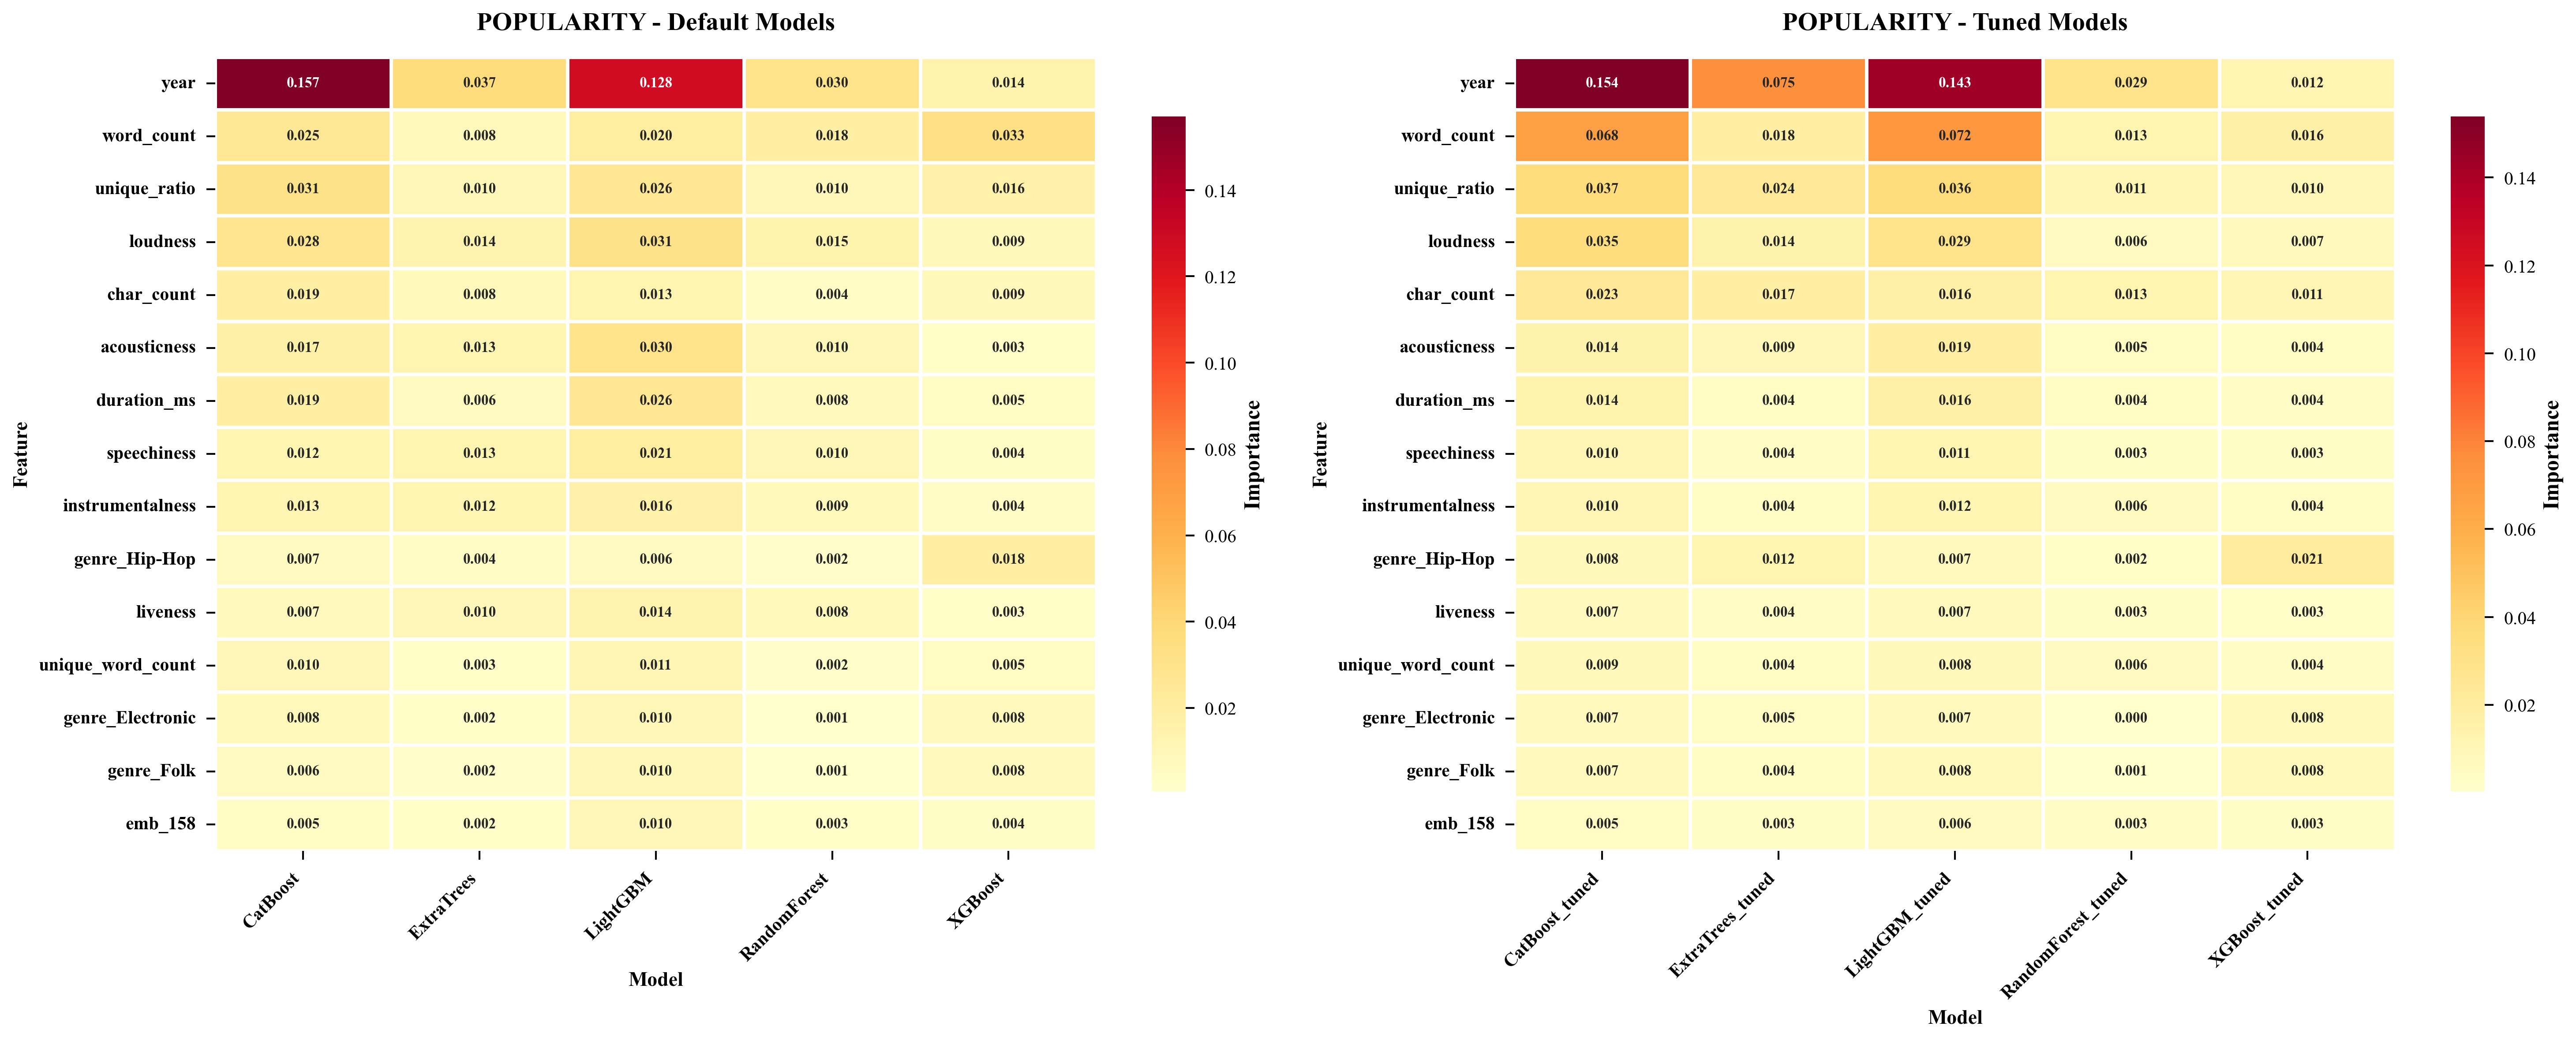

💾 Saved: feature_importance_heatmap_popularity.png


In [21]:
def plot_model_comparison(all_importance, target):
    """Compare feature importance across models"""
    target_df = all_importance[all_importance['target'] == target].copy()
    
    # Separate tuned and default models (excluding MLPRegressor)
    default_models = [m for m in SELECTED_MODELS if not m.endswith('_tuned') and 'MLPRegressor' not in m]
    tuned_models = [m for m in SELECTED_MODELS if m.endswith('_tuned') and 'MLPRegressor' not in m]
    
    # Get top 15 features overall
    top_features = target_df.groupby('feature')['importance'].mean().nlargest(15).index.tolist()
    
    # Create figure with 1 row, 2 columns
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    
    # Plot default models
    default_df = target_df[target_df['model'].isin(default_models)]
    pivot_default = default_df[default_df['feature'].isin(top_features)].pivot(
        index='feature', columns='model', values='importance'
    )
    pivot_default = pivot_default.loc[top_features]
    
    sns.heatmap(pivot_default, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax1,
                linewidths=1.5, linecolor='white',
                cbar_kws={'label': 'Importance', 'shrink': 0.85},
                annot_kws={'fontsize': 8, 'weight': 'bold'})
    ax1.set_title(f'{target.upper()} - Default Models', fontsize=14, fontweight='bold', pad=15)
    ax1.set_xlabel('Model', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Feature', fontsize=11, fontweight='bold')
    ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right', fontweight='bold')
    ax1.set_yticklabels(ax1.get_yticklabels(), rotation=0, fontweight='bold')
    
    # Plot tuned models
    tuned_df = target_df[target_df['model'].isin(tuned_models)]
    pivot_tuned = tuned_df[tuned_df['feature'].isin(top_features)].pivot(
        index='feature', columns='model', values='importance'
    )
    pivot_tuned = pivot_tuned.loc[top_features]
    
    sns.heatmap(pivot_tuned, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax2,
                linewidths=1.5, linecolor='white',
                cbar_kws={'label': 'Importance', 'shrink': 0.85},
                annot_kws={'fontsize': 8, 'weight': 'bold'})
    ax2.set_title(f'{target.upper()} - Tuned Models', fontsize=14, fontweight='bold', pad=15)
    ax2.set_xlabel('Model', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Feature', fontsize=11, fontweight='bold')
    ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right', fontweight='bold')
    ax2.set_yticklabels(ax2.get_yticklabels(), rotation=0, fontweight='bold')
    
    plt.tight_layout()
    return fig

# Generate heatmaps
for target in TARGETS:
    fig = plot_model_comparison(all_importance_df, target)
    fig_path = FIGURES_DIR / f"feature_importance_heatmap_{target}.png"
    fig.savefig(fig_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"💾 Saved: {fig_path.name}")

---
## 🔑 Key Insights: Embedding Contribution

In [22]:
print("🔑 EMBEDDING CONTRIBUTION ANALYSIS\n")
print("="*70)

embedding_cols = [f'emb_{i}' for i in range(384)]

insights = []
for target in TARGETS:
    target_df = all_importance_df[all_importance_df['target'] == target]
    emb_importance = target_df[target_df['feature'].isin(embedding_cols)]['importance'].sum()
    total_importance = target_df['importance'].sum()
    emb_pct = (emb_importance / total_importance * 100) if total_importance > 0 else 0
    
    print(f"   {target.upper():15s} → Embeddings: {emb_pct:5.1f}% of total importance")
    insights.append({'target': target, 'embedding_contribution_pct': emb_pct})

insights_df = pd.DataFrame(insights)
display(insights_df.style.format({'embedding_contribution_pct': '{:.2f}%'}).background_gradient(
    subset=['embedding_contribution_pct'], cmap='YlOrRd'
))

🔑 EMBEDDING CONTRIBUTION ANALYSIS

   VALENCE         → Embeddings:  62.0% of total importance
   ENERGY          → Embeddings:  30.4% of total importance
   DANCEABILITY    → Embeddings:  43.5% of total importance
   POPULARITY      → Embeddings:  76.4% of total importance


,target,embedding_contribution_pct
0,valence,61.97%
1,energy,30.41%
2,danceability,43.52%
3,popularity,76.40%


---
## ✅ Summary

In [23]:
print("\n" + "="*70)
print("✅ FEATURE IMPORTANCE ANALYSIS COMPLETE")
print("="*70)
print(f"📊 Models analyzed: {len(SELECTED_MODELS)} × {len(TARGETS)} targets = {len(all_importance)} combinations")
print(f"📁 Results saved to: {RESULTS_DIR}")
print(f"🖼️ Figures saved to: {FIGURES_DIR}")
print("\n🎯 Next Steps:")
print("   1. Review feature importance visualizations")
print("   2. Understand which features drive each target")
print("   3. Proceed to test evaluation (one-time final evaluation)")


✅ FEATURE IMPORTANCE ANALYSIS COMPLETE
📊 Models analyzed: 12 × 4 targets = 48 combinations
📁 Results saved to: /home/esstee/documents/bitirme/results/metrics
🖼️ Figures saved to: /home/esstee/documents/bitirme/results/figures

🎯 Next Steps:
   1. Review feature importance visualizations
   2. Understand which features drive each target
   3. Proceed to test evaluation (one-time final evaluation)
